# BNP Paribas- Bussines Case Project 2025/2026
**CLUSTERING NOTEBOOK**

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from suport import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

## 2. Data importation

In [25]:
BNP = pd.read_csv('Preprocessed_dataset_BNP.csv')

## 3. Separating Datasets and Merging

In [26]:
#separating the datasets considering the SOL and SAN features
BNP_sol = BNP[BNP['is_sol'] == 1]
BNP_san = BNP[BNP['is_san'] == 1]

In [27]:
#defining mode
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [28]:
#aggregation the dossiers by client
BNP_sol = (BNP_sol.groupby('CONTRIB').agg(
    n_dossiers=('DOSSIER', 'nunique'),
    
    DURDEG = ('DURDEG', 'mean'),
    RANGPRO = ('RANGPRO_max', 'mean'),
    RANGCLI = ('RANGCLI_max', 'mean'),
    MENSALIDADE = ('MENSALIDADE', 'mean'), 
    CRD = ('CRD_min', 'mean'),
    MTFINO = ('MTFINO', 'mean'),
    RESSO = ('RESSO_mean', 'mean'),
    RISKA = ('RISKA_mean', 'mean'),
    NBEN = ('NBENF_mean', 'mean'),
    RN = ('RN_mean', 'mean'),
    SREC = ('SREC', 'mean'),
    POLE = ('POLE', moda),
    PRODALP = ('PRODALP', moda),
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
    CHURN = ('CHURN', moda),
    count_cl = ('count_cl_mean', 'first'),
    montvenc_cl = ('montvenc_cl_mean', 'first'),
    montabatv_cl = ('montabatv_cl_mean', 'first'),
    dividas_cl = ('dividas_cl_mean', 'first'),
    subcount_total = ('subcount_total_mean', 'first'),
    montenc_total = ('montenc_total_mean', 'first'),
    montabatv_total = ('montabatv_total_mean', 'first'),
    dividas_total_mean = ('dividas_total_mean', 'first'),
    HIGH_RISK_CURRENT = ('HIGH_RISK_CURRENT', 'first'),
    kp_sqe = ('kp_sqe', 'first'),
    ks_score_tier = ('ks_score_tier', 'first'),
    is_risky = ('is_risky', 'first'), 
    ALLBD_mean_duration_CL__N = ('ALLBD_mean_duration_CL__N', 'first'),
    ALLBD_mean_lifecycle_CL__N = ('ALLBD_mean_lifecycle_CL__N', 'first'),
    ALLBD_N_events__N = ('ALLBD_N_events__N', 'first'),
    sdem_SITFAM = ('sdem_SITFAM', 'first'),
    sdem_HABITAT = ('sdem_HABITAT', 'first'),
    sdem_age = ('sdem_age', 'first'),
    active_credit_ratio = ('active_credit_ratio', 'first')
))

In [29]:
#aggregation the dossiers by client
BNP_san = (BNP_san.groupby('CONTRIB').agg(
    n_dossiers=('DOSSIER', 'nunique'),
    
    DURDEG = ('DURDEG', 'mean'),
    RANGPRO = ('RANGPRO_max', 'mean'),
    RANGCLI = ('RANGCLI_max', 'mean'),
    MENSALIDADE = ('MENSALIDADE', 'mean'), 
    CRD = ('CRD_min', 'mean'),
    MTFINO = ('MTFINO', 'mean'),
    RESSO = ('RESSO_mean', 'mean'),
    RISKA = ('RISKA_mean', 'mean'),
    NBEN = ('NBENF_mean', 'mean'),
    RN = ('RN_mean', 'mean'),
    SREC = ('SREC', 'mean'),
    POLE = ('POLE', moda),
    PRODALP = ('PRODALP', moda),
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
    CHURN = ('CHURN', moda),
    count_cl = ('count_cl_mean', 'first'),
    montvenc_cl = ('montvenc_cl_mean', 'first'),
    montabatv_cl = ('montabatv_cl_mean', 'first'),
    dividas_cl = ('dividas_cl_mean', 'first'),
    subcount_total = ('subcount_total_mean', 'first'),
    montenc_total = ('montenc_total_mean', 'first'),
    montabatv_total = ('montabatv_total_mean', 'first'),
    dividas_total_mean = ('dividas_total_mean', 'first'),
    HIGH_RISK_CURRENT = ('HIGH_RISK_CURRENT', 'first'),
    kp_sqe = ('kp_sqe', 'first'),
    ks_score_tier = ('ks_score_tier', 'first'),
    is_risky = ('is_risky', 'first'),
    ALLBD_mean_duration_CL__N = ('ALLBD_mean_duration_CL__N', 'first'),
    ALLBD_mean_lifecycle_CL__N = ('ALLBD_mean_lifecycle_CL__N', 'first'),
    ALLBD_N_events__N = ('ALLBD_N_events__N', 'first'),
    sdem_SITFAM = ('sdem_SITFAM', 'first'),
    sdem_HABITAT = ('sdem_HABITAT', 'first'),
    sdem_age = ('sdem_age', 'first'),
    active_credit_ratio = ('active_credit_ratio', 'first')
))

## 4. Data Preparation for Clustering

### 4.1. Changing Datatypes

In [30]:
#changing datatypes
BNP_sol['CHURN'] = BNP_sol['CHURN'].astype(int)
BNP_san['CHURN'] = BNP_san['CHURN'].astype(int)
BNP_sol['NBEN'] = BNP_sol['NBEN'].round().astype('Int32')
BNP_sol['count_cl'] = BNP_sol['count_cl'].round().astype('Int32')
BNP_sol['HIGH_RISK_CURRENT'] = BNP_sol['HIGH_RISK_CURRENT'].round().astype('Int32')
BNP_sol['is_risky'] = BNP_sol['is_risky'].round().astype('Int32')
BNP_san['NBEN'] = BNP_san['NBEN'].round().astype('Int32')
BNP_san['count_cl'] = BNP_san['count_cl'].round().astype('Int32')
BNP_san['HIGH_RISK_CURRENT'] = BNP_san['HIGH_RISK_CURRENT'].round().astype('Int32')
BNP_san['is_risky'] = BNP_san['is_risky'].round().astype('Int32')

### 4.2. Visualizing the data 

In [31]:
BNP_sol.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26257 entries, 0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a to fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   n_dossiers                  26257 non-null  int64  
 1   DURDEG                      26257 non-null  float64
 2   RANGPRO                     26257 non-null  float64
 3   RANGCLI                     26257 non-null  float64
 4   MENSALIDADE                 26257 non-null  float64
 5   CRD                         26257 non-null  float64
 6   MTFINO                      26257 non-null  float64
 7   RESSO                       26257 non-null  float64
 8   RISKA                       26257 non-null  float64
 9   NBEN                        26257 non-null  Int32  
 10  RN                          26257 non-null  float64
 11  SREC                        

In [32]:
BNP_san.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41162 entries, 00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981 to ffffe82f7c91df4a087341fe89db094be2a89294f2178572b937a270b0c9f669
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   n_dossiers                  41162 non-null  int64  
 1   DURDEG                      41162 non-null  float64
 2   RANGPRO                     41162 non-null  float64
 3   RANGCLI                     41162 non-null  float64
 4   MENSALIDADE                 41162 non-null  float64
 5   CRD                         41162 non-null  float64
 6   MTFINO                      41162 non-null  float64
 7   RESSO                       41162 non-null  float64
 8   RISKA                       41162 non-null  float64
 9   NBEN                        41162 non-null  Int32  
 10  RN                          41162 non-null  float64
 11  SREC                        

In [33]:
BNP_sol.describe()

,n_dossiers,DURDEG,RANGPRO,RANGCLI,MENSALIDADE,CRD,MTFINO,RESSO,RISKA,NBEN,...,montabatv_total,dividas_total_mean,HIGH_RISK_CURRENT,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,active_credit_ratio
count,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.0,...,26257.000000,26257.000000,26257.0,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000
mean,1.034429,53.116564,46.756365,52.611488,171.747250,0.0,5855.352467,1444.841921,0.030498,0.607457,...,13.634376,33633.267661,0.138782,1.202689,0.860609,24.286032,0.277626,7.834977,48.184636,0.144943
std,0.199106,23.459343,23.650478,27.918834,127.342656,0.0,4894.305769,4511.684187,0.181445,0.837112,...,693.839408,43274.173982,0.345726,0.591405,0.346361,31.909492,0.372294,5.107468,12.292106,0.146711
min,1.000000,11.000000,2.000000,2.000000,8.986745,0.0,300.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,1.000000,0.0,0.000000,0.000000,1.000000,19.000000,0.000000
25%,1.000000,36.000000,24.000000,35.000000,98.389630,0.0,2500.000000,893.495000,0.000000,0.0,...,0.000000,5601.021667,0.0,1.000000,1.0,0.000000,0.000000,4.000000,39.000000,0.000000
50%,1.000000,59.000000,42.000000,48.000000,133.210021,0.0,5000.000000,1145.966000,0.000000,0.0,...,0.000000,25702.332800,0.0,1.000000,1.0,0.000000,0.000000,7.000000,47.000000,0.125000
75%,1.000000,72.000000,72.000000,72.000000,209.995221,0.0,7010.000000,1650.147000,0.000000,1.0,...,0.000000,34569.331053,0.0,1.000000,1.0,48.000000,0.666667,10.000000,57.000000,0.222222
max,7.000000,156.000000,120.000000,368.000000,3166.392662,0.0,65000.000000,700000.000000,5.133333,6.0,...,85972.660000,544613.300000,1.0,5.000000,1.0,131.000000,1.000000,70.000000,85.000000,0.833333


In [34]:
BNP_san.describe()

,n_dossiers,DURDEG,RANGPRO,RANGCLI,MENSALIDADE,CRD,MTFINO,RESSO,RISKA,NBEN,...,montabatv_total,dividas_total_mean,HIGH_RISK_CURRENT,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,active_credit_ratio
count,41162.000000,41162.000000,41162.000000,41162.000000,41162.000000,41162.0,41162.000000,41162.000000,41162.000000,41162.0,...,41162.000000,41162.000000,41162.0,41162.000000,41162.0,41162.000000,41162.000000,41162.000000,41162.000000,41162.000000
mean,1.202201,73.043261,28.165813,40.504554,215.139622,0.0,9676.309649,1472.245814,0.030806,0.646494,...,6.196211,57859.317330,0.202152,1.193625,0.867475,45.201952,0.166958,9.933409,43.585054,0.154117
std,0.541876,28.893104,22.259841,26.952195,172.441019,0.0,8866.075121,924.534728,0.201309,0.842425,...,219.348020,60447.161645,0.40161,0.547024,0.339065,44.383812,0.231548,6.762982,11.480855,0.136118
min,1.000000,12.000000,0.000000,0.000000,3.377646,0.0,300.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,1.000000,0.0,0.000000,0.000000,1.000000,18.000000,0.000000
25%,1.000000,48.000000,11.000000,20.000000,105.625766,0.0,4000.000000,994.955476,0.000000,0.0,...,0.000000,15641.072400,0.0,1.000000,1.0,0.000000,0.000000,5.000000,35.000000,0.055556
50%,1.000000,84.000000,22.000000,36.000000,161.810844,0.0,6500.000000,1240.201000,0.000000,0.0,...,0.000000,32028.776600,0.0,1.000000,1.0,40.000000,0.058088,8.000000,43.000000,0.130435
75%,1.000000,84.000000,41.000000,56.000000,268.244378,0.0,12500.000000,1730.428000,0.000000,1.0,...,0.000000,85519.871133,0.0,1.000000,1.0,84.000000,0.250000,13.000000,51.000000,0.222222
max,9.000000,156.000000,110.000000,356.000000,4000.000000,0.0,75000.000000,33930.100000,5.250000,10.0,...,30347.420000,649582.985000,1.0,5.000000,1.0,156.000000,1.000000,70.000000,85.000000,0.833333


In [35]:
#defining metric features 
metric_features = ['n_dossiers', 'DURDEG', 'RANGPRO', 'RANGCLI', 'MENSALIDADE', 'CRD', 
                   'MTFINO', 'RESSO', 'RISKA', 'NBEN', 'RN', 'SREC', 'count_cl', 'montvenc_cl',
                   'montabatv_cl', 'dividas_cl', 'subcount_total', 'montenc_total', 
                   'montabatv_total', 'dividas_total_mean', 'ks_score_tier', 'ALLBD_mean_duration_CL__N', 
                   'ALLBD_mean_lifecycle_CL__N', 'ALLBD_N_events__N', 'sdem_age', 'active_credit_ratio'] 

In [36]:
#defining categorical features
non_metric_features = ['POLE', 'PRODALP', 'AGFIN ', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO', 
                       'CHURN', 'HIGH_RISK_CURRENT', 'kp_sqe', 'is_risky', 'sdem_SITFAM', 'sdem_HABITAT'] 

In [37]:
df_sol= pd.DataFrame(BNP_sol[metric_features])
df_san= pd.DataFrame(BNP_san[metric_features])

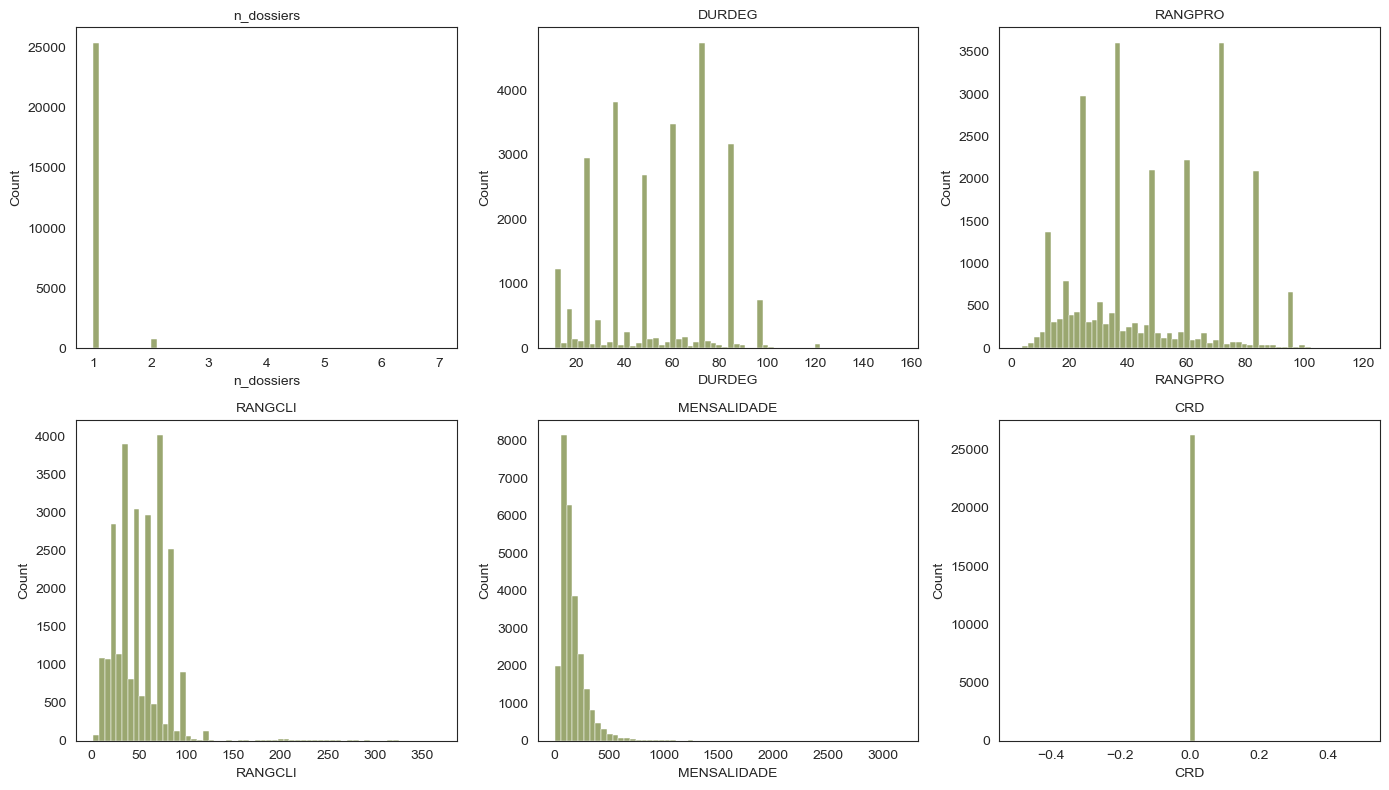

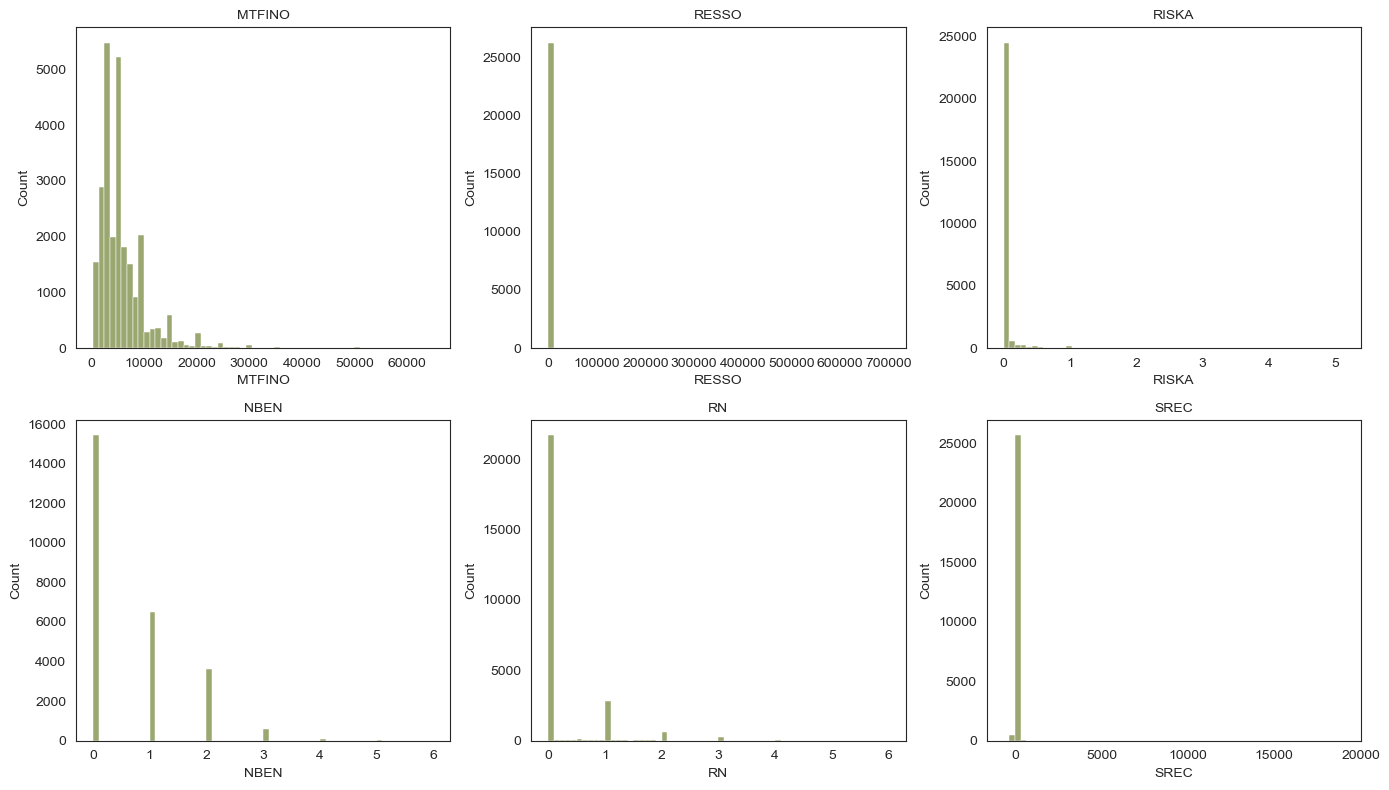

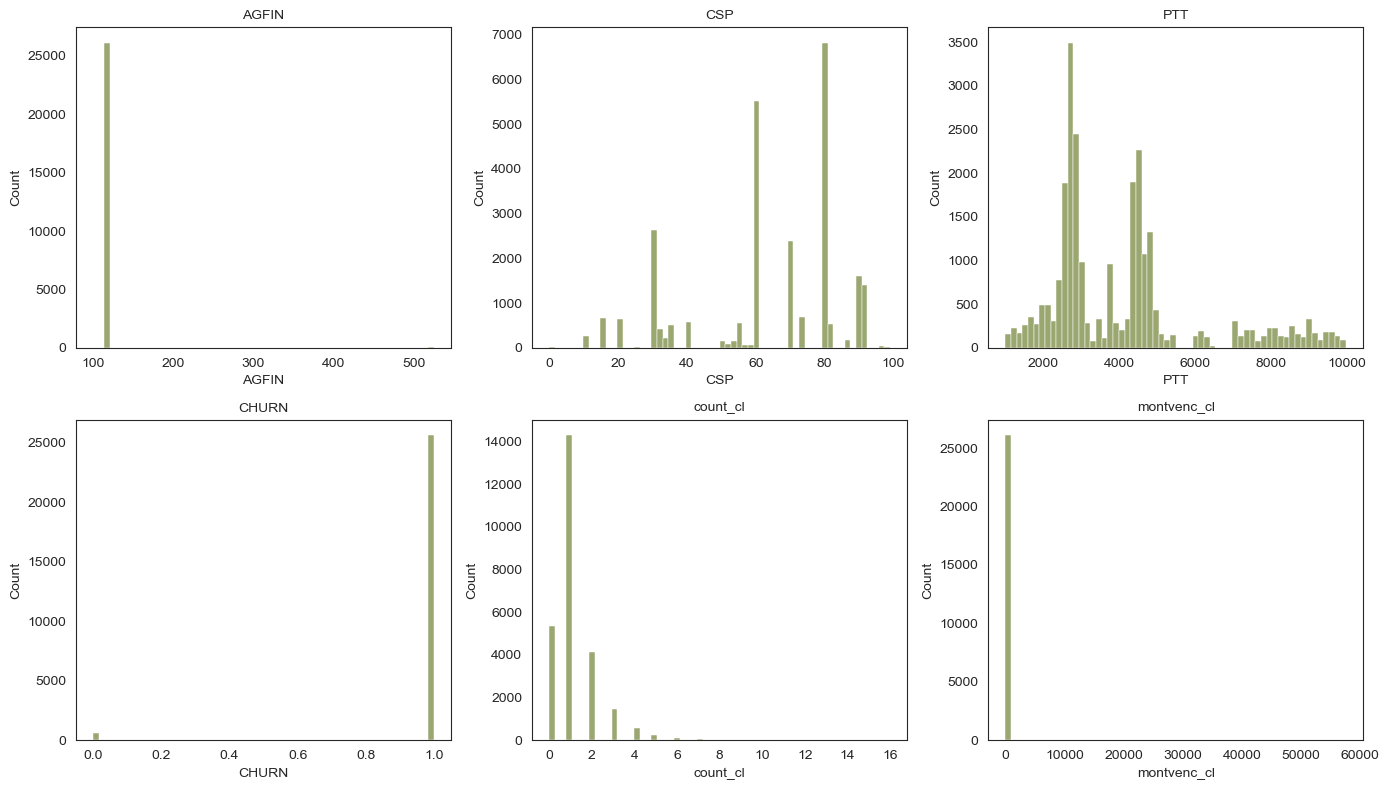

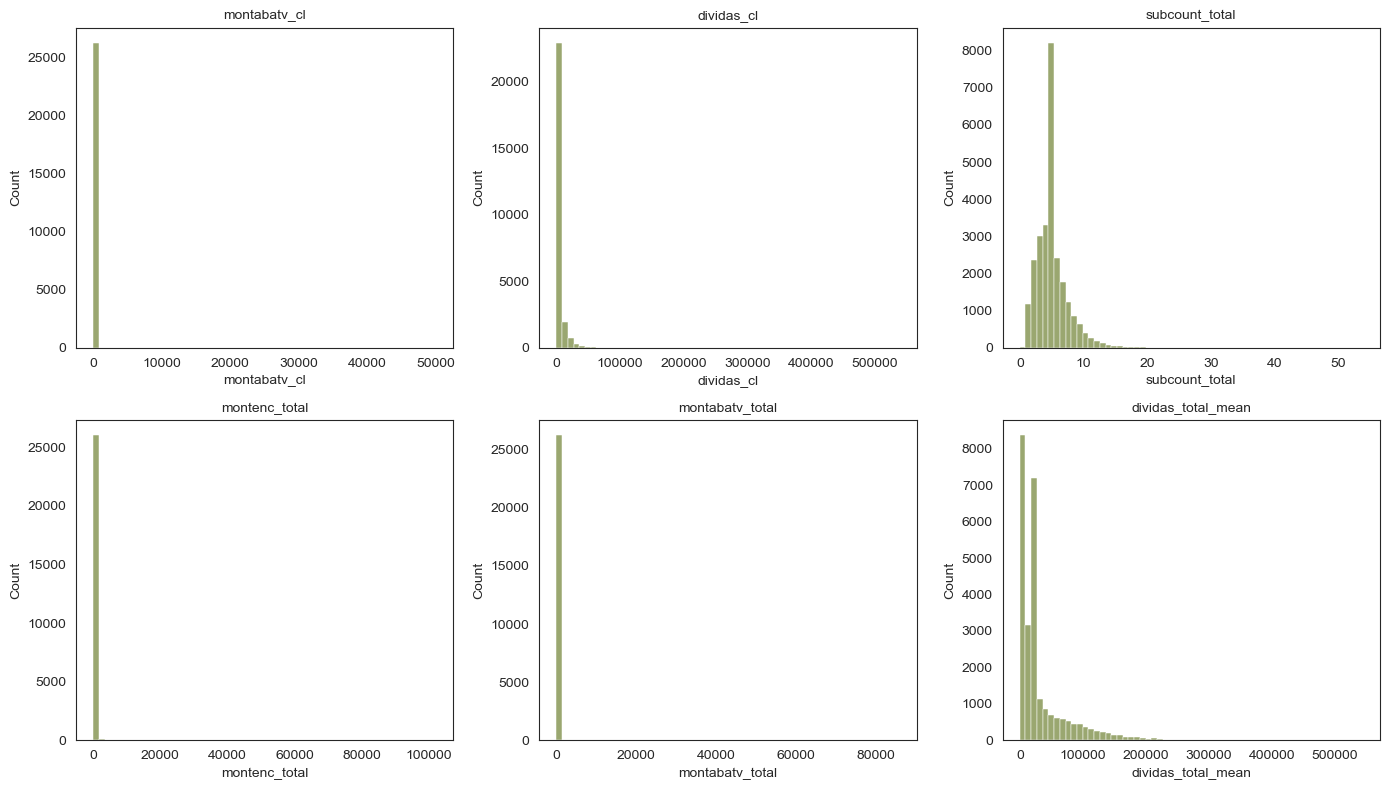

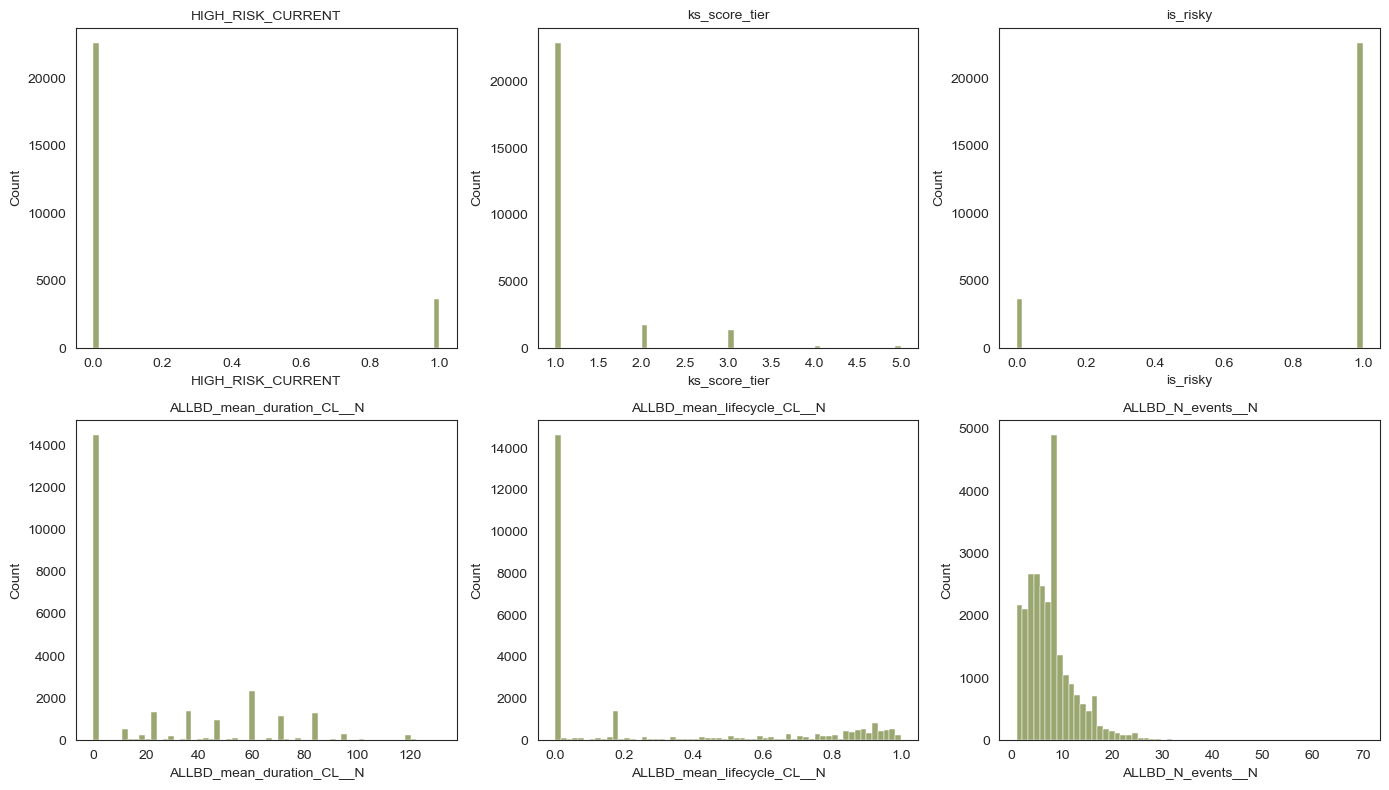

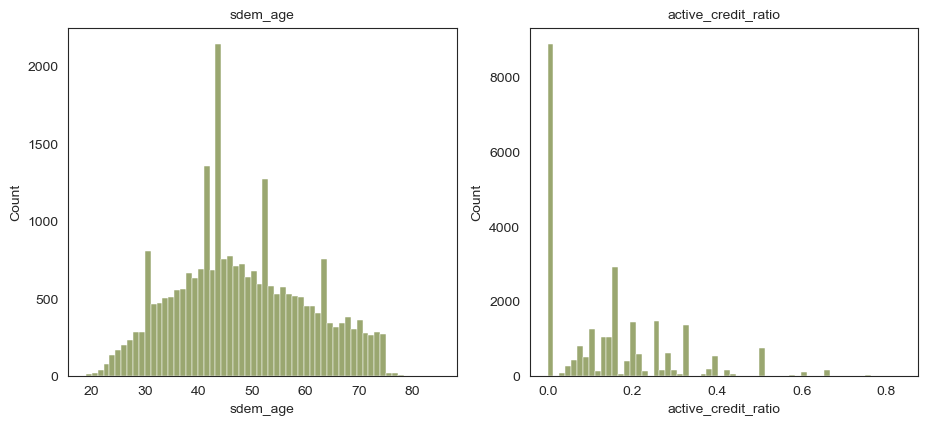

In [38]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = BNP_sol.sample(n=min(N, len(BNP_sol)), random_state=42)

#selecting numeric variables
cols = sample.select_dtypes(include=[np.number]).columns

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

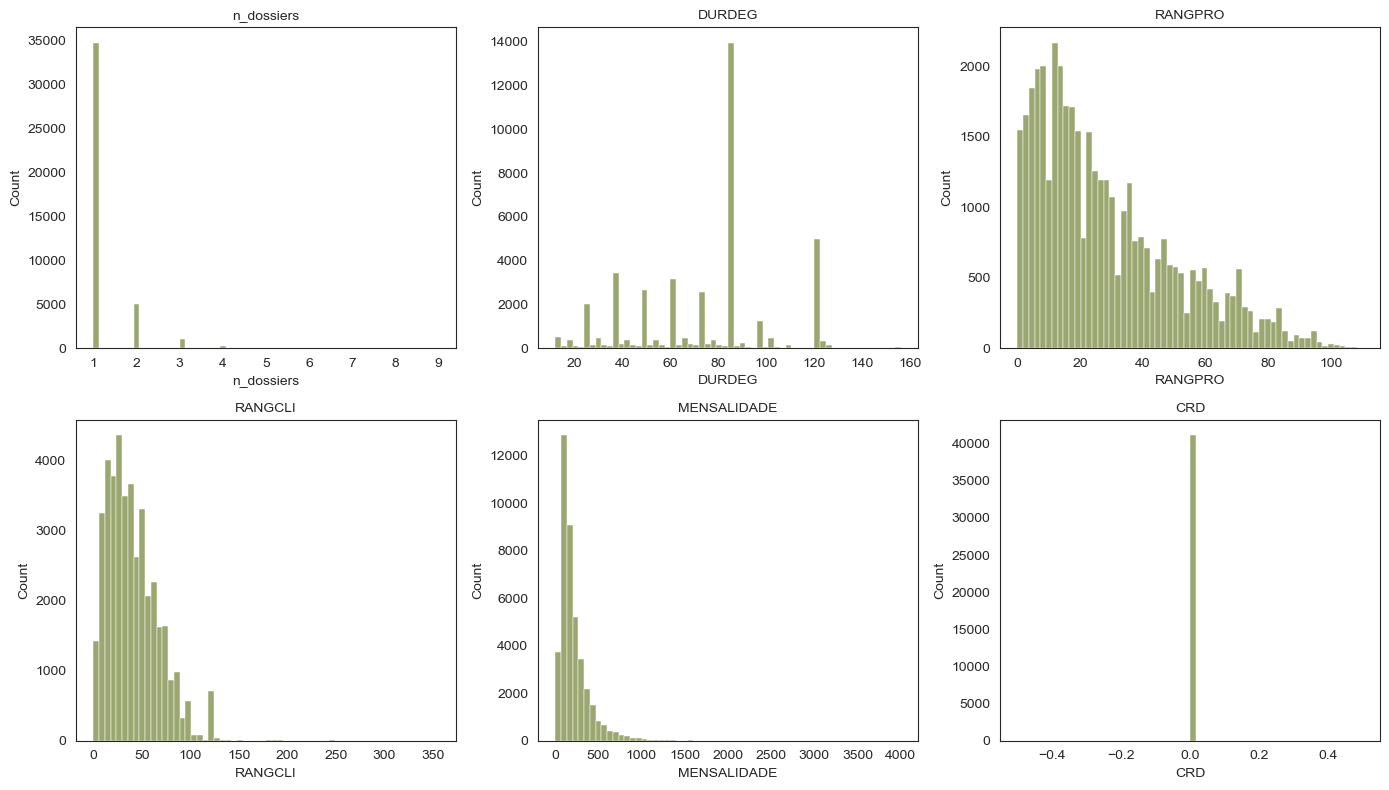

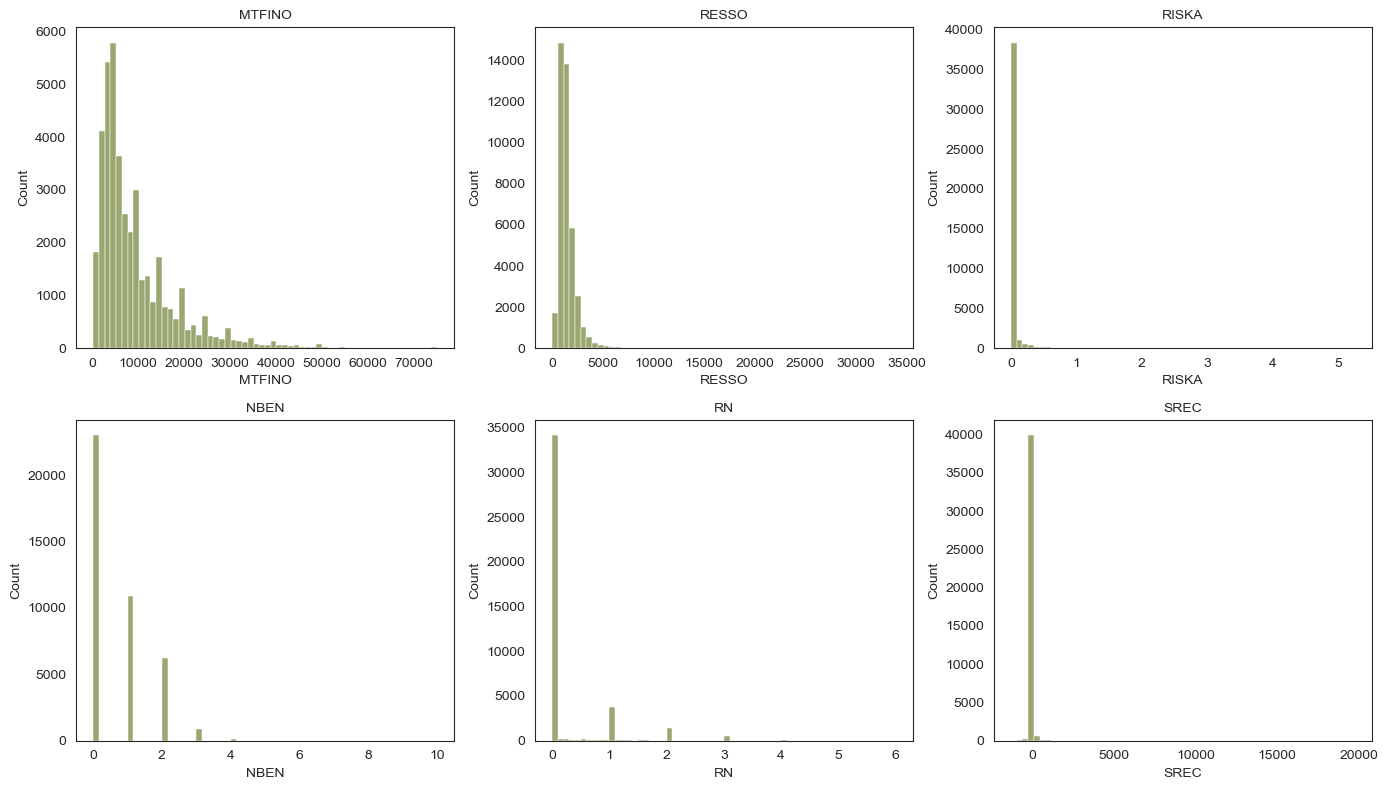

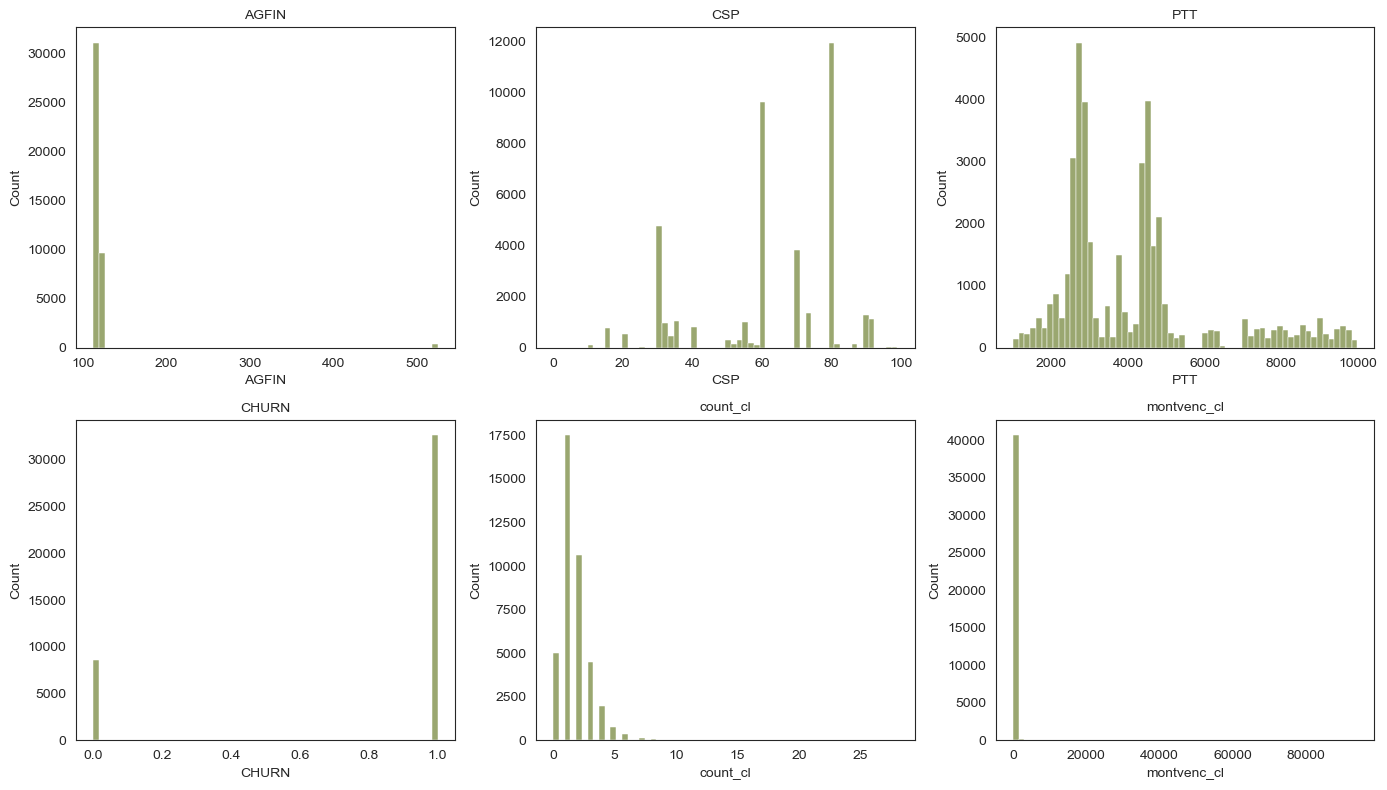

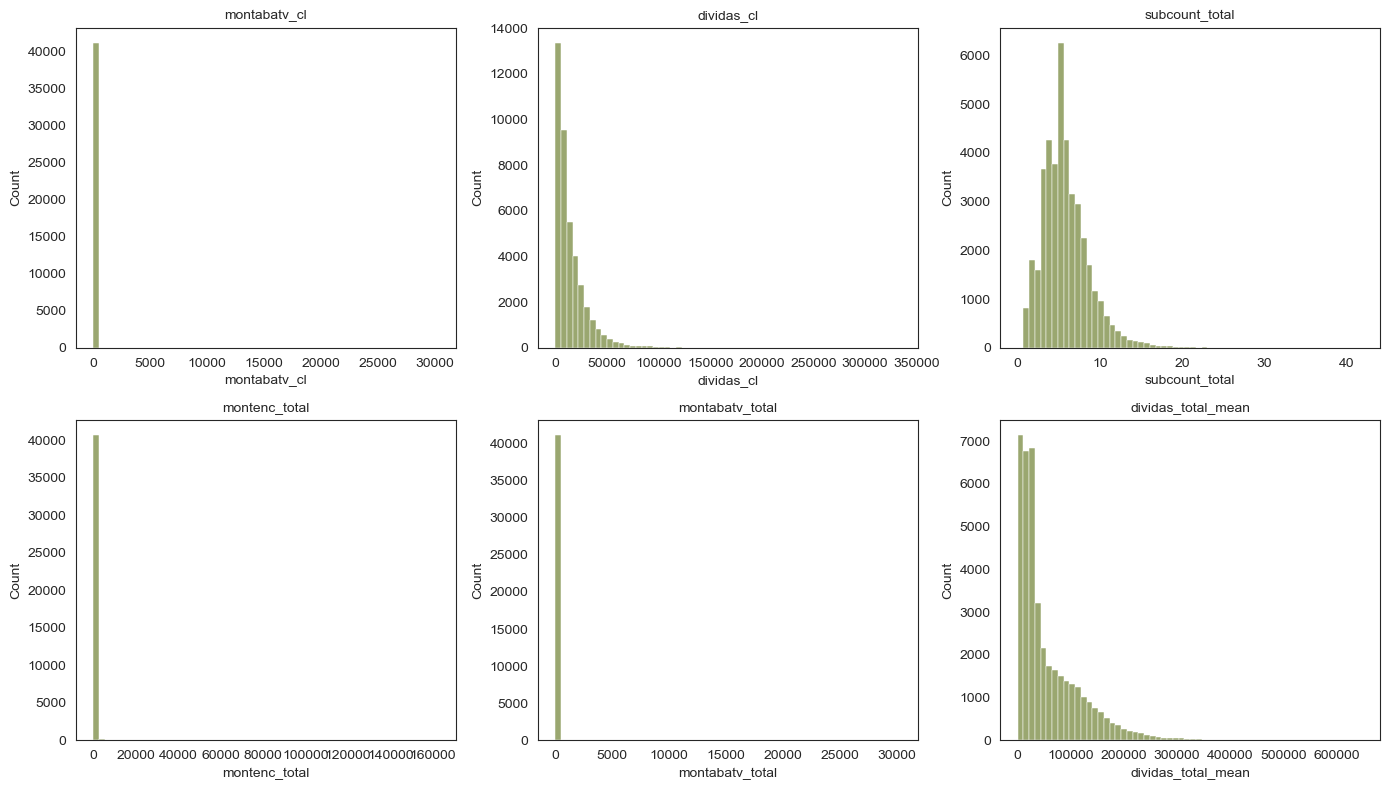

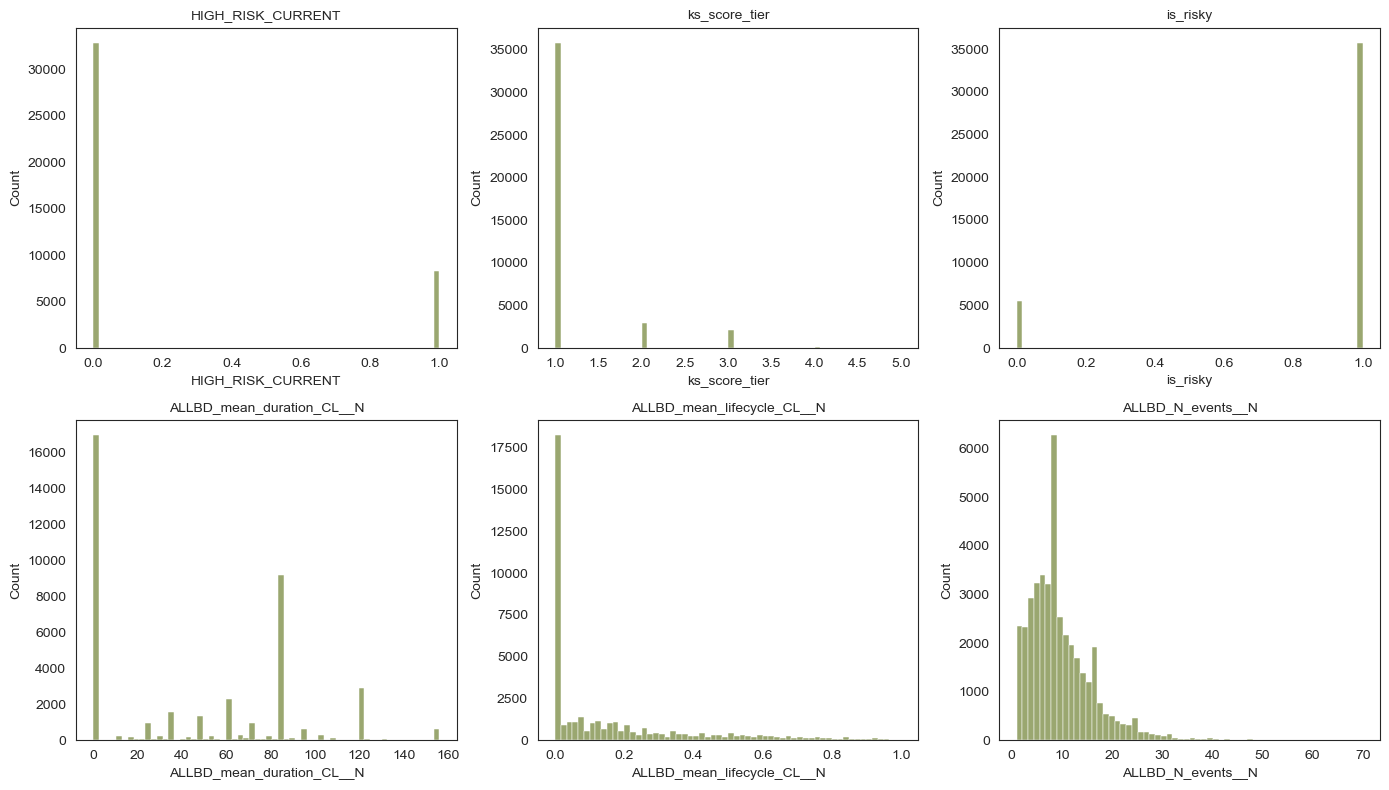

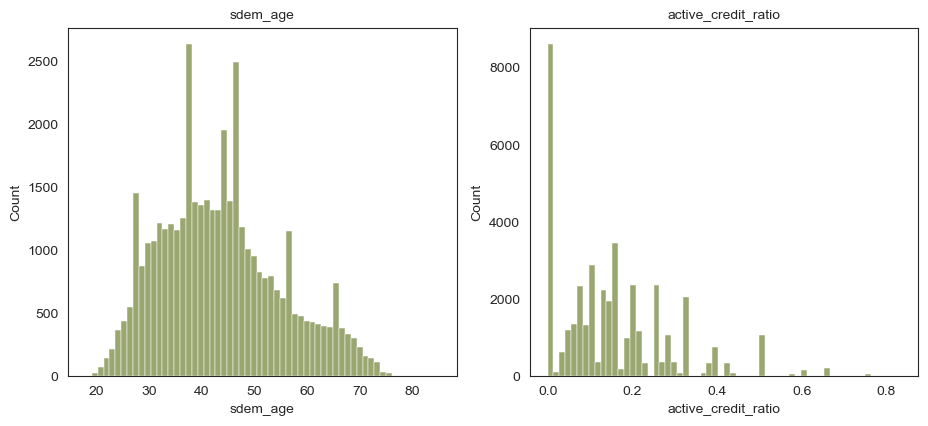

In [39]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = BNP_san.sample(n=min(N, len(BNP_san)), random_state=42)

#selecting numeric variables
cols = sample.select_dtypes(include=[np.number]).columns

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

### 4.3. Feature Engineering

In [40]:
#creating the variable 'IncomeCategory' that indicates whether a customer has low, middle or high income
BNP_sol['LowIncome'] = np.where (BNP_sol['RESSO'] < 1000, 'Low Income', None)
BNP_sol['MiddleIncome'] = np.where((BNP_sol['RESSO'] >= 1000) & (BNP_sol['RESSO'] <= 3500), 'Middle Income', None)
BNP_sol['HighIncome'] = np.where (BNP_sol['RESSO'] > 3500, 'High Income', None)

BNP_sol['IncomeCategory'] = BNP_sol['HighIncome'].combine_first(BNP_sol['LowIncome']).combine_first(BNP_sol['MiddleIncome'])
BNP_sol.drop(columns=['HighIncome', 'LowIncome', 'MiddleIncome'], inplace=True)

In [41]:
#creating the variable 'IncomeCategory' that indicates whether a customer has low, middle or high income
BNP_san['LowIncome'] = np.where (BNP_san['RESSO'] < 1000, 'Low Income', None)
BNP_san['MiddleIncome'] = np.where((BNP_san['RESSO'] >= 1000) & (BNP_san['RESSO'] <= 3500), 'Middle Income', None)
BNP_san['HighIncome'] = np.where (BNP_san['RESSO'] > 3500, 'High Income', None)

BNP_san['IncomeCategory'] = BNP_san['HighIncome'].combine_first(BNP_san['LowIncome']).combine_first(BNP_san['MiddleIncome'])
BNP_san.drop(columns=['HighIncome', 'LowIncome', 'MiddleIncome'], inplace=True)

In [42]:
BNP_sol['IncomeCategory'].value_counts()

IncomeCategory
Middle Income    15594
Low Income        9799
High Income        864
Name: count, dtype: int64

In [43]:
BNP_san['IncomeCategory'].value_counts()

IncomeCategory
Middle Income    29483
Low Income       10543
High Income       1136
Name: count, dtype: int64

In [44]:
#creating binary variables to indicate the following:
BNP_sol['has_overdue']  = (BNP_sol['montvenc_cl'] > 0).astype(int)
BNP_sol['has_writeoff'] = (BNP_sol['montabatv_total'] > 0).astype(int)
BNP_sol['has_recovery'] = (BNP_sol['RN'] > 0).astype(int)
BNP_san['has_overdue']  = (BNP_san['montvenc_cl'] > 0).astype(int)
BNP_san['has_writeoff'] = (BNP_san['montabatv_total'] > 0).astype(int)
BNP_san['has_recovery'] = (BNP_san['RN'] > 0).astype(int)

### 4.4. Feature Selection

#### 4.4.1. Variance

In [45]:
#checking metric features' variance 
BNP_san[metric_features].var()

n_dossiers                             0.293629
DURDEG                               834.811437
RANGPRO                              495.500542
RANGCLI                              726.420821
MENSALIDADE                         29735.90502
CRD                                         0.0
MTFINO                          78607288.058569
RESSO                             854764.462448
RISKA                                  0.040525
NBEN                                    0.70968
RN                                     0.379561
SREC                               51157.930463
count_cl                               1.874216
montvenc_cl                      1800474.102108
montabatv_cl                       33858.459413
dividas_cl                      314789051.65256
subcount_total                         8.220582
montenc_total                     4597924.81067
montabatv_total                    48113.553886
dividas_total_mean            3653859350.944413
ks_score_tier                          0

- *CRD* is a constant variable, so it is not useful.
- *RISKA* has 90% of the observations with the value 0, so we consider that this feature is quasi-constant.

In [46]:
#checking metric features' variance 
BNP_sol[metric_features].var()

n_dossiers                            0.039643
DURDEG                               550.34079
RANGPRO                               559.3451
RANGCLI                             779.461264
MENSALIDADE                       16216.152107
CRD                                        0.0
MTFINO                         23954228.964335
RESSO                          20355294.201054
RISKA                                 0.032922
NBEN                                  0.700756
RN                                    0.332293
SREC                              61152.923095
count_cl                              1.251905
montvenc_cl                      786528.667604
montabatv_cl                     152188.728855
dividas_cl                     92366627.372698
subcount_total                        6.500638
montenc_total                   2343596.635229
montabatv_total                  481413.124318
dividas_total_mean            1872654133.81721
ks_score_tier                          0.34976
ALLBD_mean_du

In [47]:
BNP_sol['RISKA'].value_counts(normalize=True).head()

RISKA
0.000000    0.912557
1.000000    0.005713
0.333333    0.004646
0.111111    0.003923
0.500000    0.003885
Name: proportion, dtype: float64

#### 4.4.2. Redundancy and Relevance

In [48]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman_san= BNP_san[metric_features].corr(method ='spearman')
cor_spearman_sol= BNP_sol[metric_features].corr(method ='spearman')

In [49]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

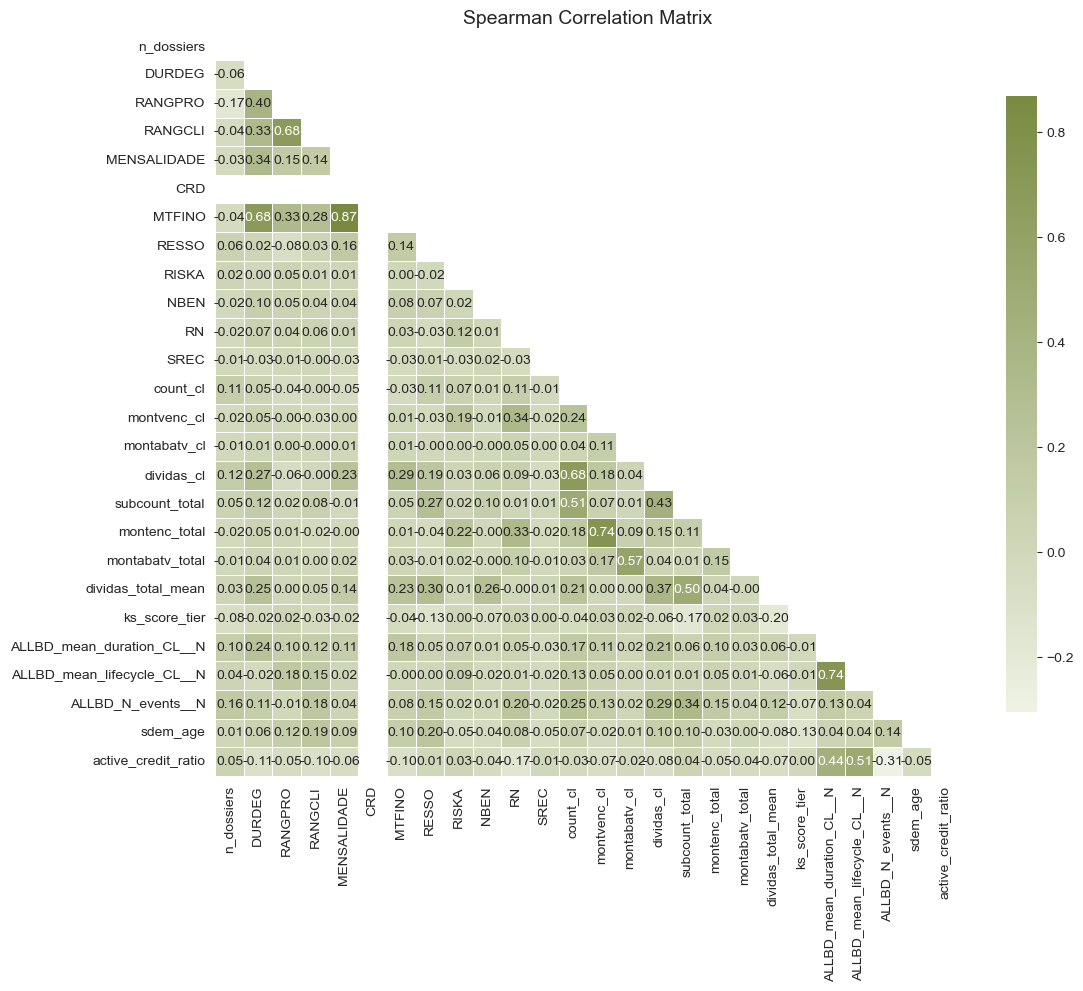

In [50]:
#applying the function to our numerical features
cor_heatmap(cor_spearman_san)

Redundant Features (Considering >0.8): 
- *MENSALIDADE* vs *MTFINO* (0.87)

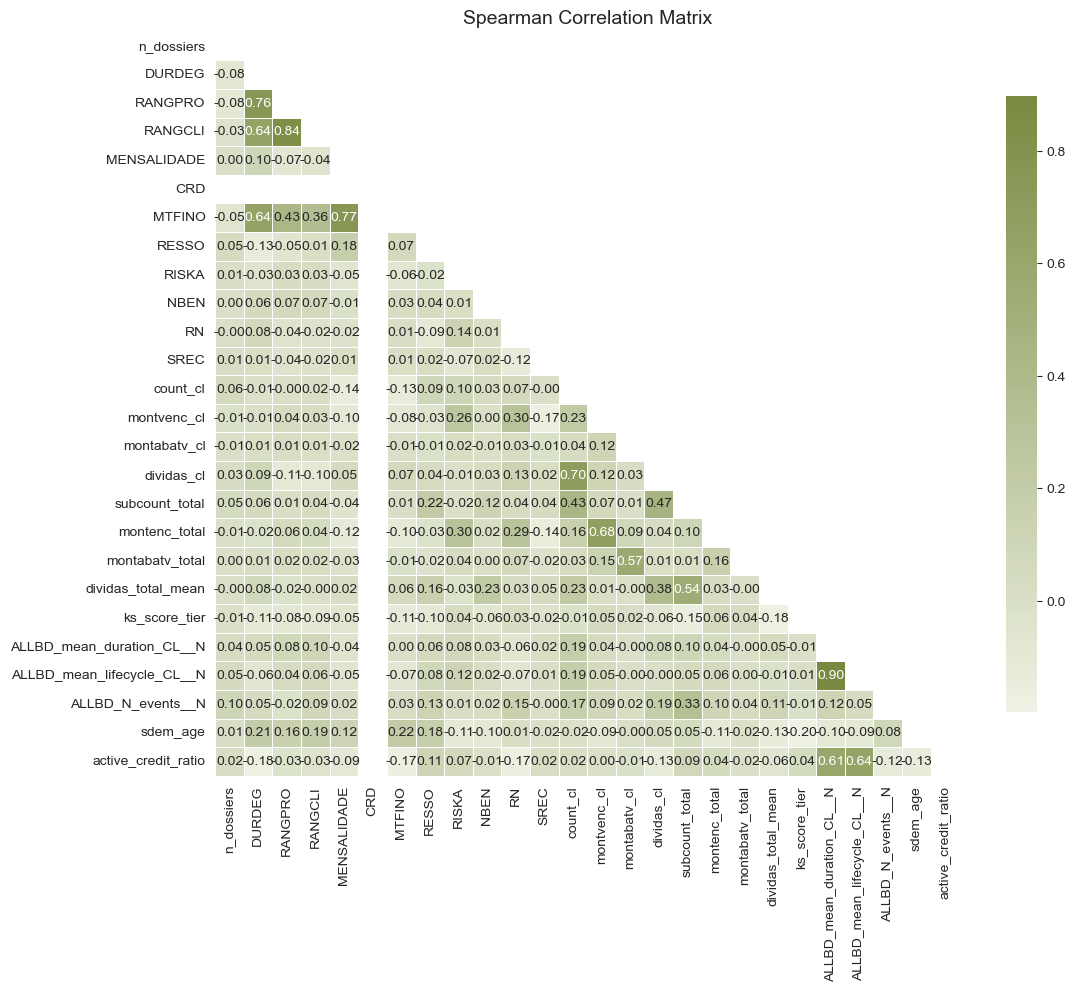

In [51]:
#applying the function to our numerical features
cor_heatmap(cor_spearman_sol)

Redundant Features (Considering >0.8): 
- *RANGCLI* vs *RANGPRO* (0.84)
- *dividas_cl* vs *count_cl* (0.81)
- *ALLBD_mean_lifecycle_CL_N* vs **ALLBD_mean_duration_CL_N* (0.90)

In [52]:
#droping redundant features
BNP_sol.drop(['RANGPRO', 'dividas_cl', 'ALLBD_mean_lifecycle_CL__N', 'CRD', 'RISKA'], axis=1, inplace=True)
BNP_san.drop(['RANGPRO', 'dividas_cl', 'ALLBD_mean_lifecycle_CL__N', 'CRD', 'RISKA'], axis=1, inplace=True)

In [53]:
#categorical features
non_metric_features = ['POLE', 'PRODALP', 'AGFIN ', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO', 
                       'CHURN', 'HIGH_RISK_CURRENT', 'kp_sqe', 'is_risky', 'sdem_SITFAM', 'sdem_HABITAT', 
                       'has_overdue', 'has_writeoff', 'has_recovery'] 

In [54]:
BNP_sol['CSP'].value_counts()

CSP
80    6821
60    5526
70    2394
31    2151
90    1604
91    1007
74     697
15     672
20     634
81     530
35     521
30     476
41     475
56     460
32     417
92     403
10     275
33     185
86     175
50     148
54     122
40     111
55      91
52      83
58      72
57      61
96      43
34      33
53      32
99      17
25      10
0        9
51       2
Name: count, dtype: int64

In [55]:
#how many clients exists for each classification (Alphabetical order)
BNP_sol['kp_sqe'] \
    .value_counts(dropna=False) \
    .sort_index()

kp_sqe
A           1924
B            857
C            566
D            580
E            737
F            672
G            382
H            480
I            138
J             62
K             39
M              7
U             92
Unknown    19598
V              2
W            121
Name: count, dtype: int64

Considering Relevance and Redundancy, we have decided to keep the following features: 
- 'ALLBD_N_events__N'
- 'DURDEG'
- 'NBEN'
- 'count_cl'
- 'montenc_total'
- 'RANGCLI'
- 'ks_score_tier'
- 'sdem_age'
- 'POLE'
- 'PRODALP'
- 'AGFIN'
- 'PAGAMENTO'
- 'NATIO'
- 'PTT'
- 'CHURN'
- 'is_risky'
- 'sdem_HABITAT'
- 'HIGH_RISK_CURRENT'
- 'CSP'

### 4.5. Scaling

In [56]:
#log transform the skewed variables
skewed_vars = [
    'NBEN',
    'montvenc_cl',
    'montabatv_cl',
    'montenc_total',
    'montabatv_total',
    'ALLBD_mean_duration_CL__N',
    'ks_score_tier'
]

BNP_sol[skewed_vars] = np.log1p(BNP_sol[skewed_vars])
BNP_san[skewed_vars] = np.log1p(BNP_san[skewed_vars])

In [57]:
#naming the features that have a log transformation
for col in skewed_vars:
    BNP_sol[f'{col}_log'] = np.log1p(BNP_sol[col])
    BNP_san[f'{col}_log'] = np.log1p(BNP_san[col])

In [58]:
#droping unecessary features
BNP_sol.drop(columns=skewed_vars, inplace=True)
BNP_san.drop(columns=skewed_vars, inplace=True)

In [62]:
#redifining metric features
metric_features = ['n_dossiers', 'DURDEG', 'RANGCLI', 'MTFINO', 'NBEN_log', 'RN', 'SREC', 'count_cl', 'montvenc_cl_log',
                   'montabatv_cl_log', 'subcount_total', 'montenc_total_log', 
                   'montabatv_total_log', 'dividas_total_mean', 'ks_score_tier_log', 'ALLBD_mean_duration_CL__N_log', 
                   'ALLBD_N_events__N', 'sdem_age'] 

In [63]:
#applying Robust Scaler in both datasets
scaler_sol = RobustScaler()
BNP_sol_scaling = scaler_sol.fit_transform(BNP_sol[metric_features])
BNP_sol_scaled = pd.DataFrame(BNP_sol_scaling, columns=BNP_sol[metric_features].columns, index=BNP_sol[metric_features].index)

scaler_san = RobustScaler()
BNP_san_scaling = scaler_san.fit_transform(BNP_san[metric_features])
BNP_san_scaled = pd.DataFrame(BNP_san_scaling, columns=BNP_san[metric_features].columns, index=BNP_san[metric_features].index)

In [ ]:
BNP_sol = BNP_sol.copy()

# drop original unscaled metric features
BNP_sol.drop(columns=metric_features, inplace=True)

# add scaled versions
BNP_sol = BNP_sol.join(BNP_sol_scaled)

BNP_sol.head()

,MENSALIDADE,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,...,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio
CONTRIB,,,,,,,,,,,,,,,,,,,,,
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,304.456898,P,EP,117.0,P,60,P,2745,T,1,...,0.000000,0.0,0.0,0.032483,0.0,1.027593,0.166667,-0.166667,0.1875,3.140861
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,274.916857,P,EP,117.0,P,86,P,2835,W,1,...,0.000000,0.0,0.0,0.032483,0.0,0.000000,0.000000,1.500000,-0.5625,2.166296
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa,129.197279,P,EP,117.0,P,80,P,4400,A,1,...,0.805000,0.0,0.0,-0.836882,0.0,0.813652,-0.333333,0.555556,2.4375,0.008011
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,128.983684,P,EP,118.0,P,60,P,9680,A,1,...,0.180714,0.0,0.0,1.125101,0.0,0.000000,0.333333,-0.333333,-0.1125,0.264469
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6,147.460428,P,EPF,117.0,P,74,P,8135,W,1,...,-1.725000,0.0,0.0,1.021097,0.0,0.000000,-0.166667,-0.277778,-0.5625,0.109575


In [64]:
BNP_san = BNP_san.copy()

# drop original unscaled metric features
BNP_san.drop(columns=metric_features, inplace=True)

# add scaled versions
BNP_san = BNP_san.join(BNP_san_scaled)

BNP_san.head()

,MENSALIDADE,RESSO,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,...,montvenc_cl_log,montabatv_cl_log,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age
CONTRIB,,,,,,,,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,219.380678,1454.729750,P,EP,118.0,P,74,P,8600,W,...,0.0,0.0,0.000000,0.0,0.0,-0.212261,0.214687,0.121991,0.250,-0.6250
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,56.017772,838.186000,P,EP,120.0,N,91,P,2855,A,...,0.0,0.0,-0.024691,0.0,0.0,-0.077069,0.000000,-0.915114,-0.625,1.6250
0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5,106.760743,2373.895000,P,EP,118.0,P,35,P,4425,W,...,0.0,0.0,0.025814,0.0,0.0,0.479879,0.000000,-0.012996,0.125,0.4375
000803da8192598bfa2bbd780df6da11b3fe54ff3327487821f060bd3de69e76,150.272552,1534.146000,P,EP,120.0,P,60,P,2870,W,...,0.0,0.0,-0.000686,0.0,0.0,2.088100,0.000000,-0.012996,-0.625,-0.7500
000a129438776dca90f4359642f343cb037d9afe60897fd1676ac48cd21d2046,558.572694,1053.336462,P,DEF,117.0,P,70,P,6200,A,...,0.0,0.0,-0.827160,0.0,0.0,-0.132670,0.000000,0.047764,0.375,0.1250


### 4.6. Encoding

In [65]:
#encoding kp_sqe in order to have less categories
kp_map = {
    'A': 'Low Risk', 'B': 'Low Risk', 'C': 'Low Risk',
    
    'D': 'Low/Middle Risk', 'E': 'Low/Middle Risk',
    'F': 'Low/Middle Risk', 'G': 'Low/Middle Risk',
    
    'H': 'Middle/High Risk', 'I': 'Middle/High Risk',
    'J': 'Middle/High Risk', 'K': 'Middle/High Risk',
    
    'M': 'High Risk', 'U': 'High Risk',
    'V': 'High Risk', 'W': 'High Risk',
    
    'Unknown': 'Unknown'
}

BNP_sol['kp_sqe_group'] = BNP_sol['kp_sqe'].map(kp_map)
BNP_san['kp_sqe_group'] = BNP_san['kp_sqe'].map(kp_map)

In [66]:
#how many clients exists for each classification (Alphabetical order)
BNP_sol['kp_sqe_group'].value_counts()

kp_sqe_group
Unknown             19598
Low Risk             3347
Low/Middle Risk      2371
Middle/High Risk      719
High Risk             222
Name: count, dtype: int64

In [67]:
#encoding CSP in order to have less categories
csp_groups = {
    # Highly qualified professionals
    20: 'highly_qualified',
    30: 'highly_qualified',
    31: 'highly_qualified',
    32: 'highly_qualified',
    33: 'highly_qualified',
    34: 'highly_qualified',
    40: 'highly_qualified',
    41: 'highly_qualified',

    # Skilled
    10: 'skilled',
    15: 'skilled',
    35: 'skilled',
    60: 'skilled',
    70: 'skilled',
    74: 'skilled',

    # Operational workers
    80: 'operational_worker',
    81: 'operational_worker',
    86: 'operational_worker',

    # Inactive worker
    25: 'inactive_worker',
    90: 'inactive_worker',
    91: 'inactive_worker',
    92: 'inactive_worker',
    96: 'inactive_worker',
    99: 'inactive_worker',

    # Confidential jobs
    50: 'Confidential job',
    51: 'Confidential job',
    52: 'Confidential job',
    53: 'Confidential job',
    54: 'Confidential job',
    55: 'Confidential job',
    56: 'Confidential job',
    57: 'Confidential job',
    58: 'Confidential job'
}

BNP_sol['CSP_group'] = BNP_sol['CSP'].map(csp_groups)
BNP_san['CSP_group'] = BNP_san['CSP'].map(csp_groups)

In [68]:
#how many clients exists for each classification (Alphabetical order)
BNP_sol['CSP_group'].value_counts()

CSP_group
skilled               10085
operational_worker     7526
highly_qualified       4482
inactive_worker        3084
Confidential job       1071
Name: count, dtype: int64

In [69]:
#encoding PTT in order to have less categories
def map_region(cp4):
    
    cp4 = int(cp4)
    
    if 1000 <= cp4 <= 1999:
        return 'Lisboa'
    
    elif 2000 <= cp4 <= 3999 or 6000 <= cp4 <= 6999:
        return 'Centro'
    
    elif 4000 <= cp4 <= 5999:
        return 'Norte'
    
    elif 7000 <= cp4 <= 7999:
        return 'Alentejo'
    
    elif 8000 <= cp4 <= 8999:
        return 'Algarve'
    
    else:
        return 'Arquipélagos'

In [70]:
BNP_sol['region'] = BNP_sol['PTT'].apply(map_region)
BNP_san['region'] = BNP_san['PTT'].apply(map_region)

In [71]:
#redifining non metric features
non_metric_features = ['PRODALP', 'CSP_group', 'region', 'MODCONTACTO', 'CHURN', 'HIGH_RISK_CURRENT',
                        'kp_sqe_group', 'is_risky', 'sdem_SITFAM', 'sdem_HABITAT',
                        'has_overdue', 'has_writeoff', 'has_recovery', 'IncomeCategory'] 

## 5. Clustering

#### 5.1. Selecting Relevant Features

In [72]:
BNP_sol.describe()

,n_dossiers,DURDEG,RANGCLI,MENSALIDADE,MTFINO,RESSO,RN,SREC,AGFIN,CSP,...,has_overdue,has_writeoff,has_recovery,NBEN_log,montvenc_cl_log,montabatv_cl_log,montenc_total_log,montabatv_total_log,ALLBD_mean_duration_CL__N_log,ks_score_tier_log
count,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,...,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000
mean,1.034429,53.116564,52.611488,171.747250,5855.352467,1444.841921,0.224851,7.969287,119.576303,63.267852,...,0.064821,0.004532,0.175077,0.256086,0.095274,0.002855,0.197581,0.008521,0.707625,0.562938
std,0.199106,23.459343,27.918834,127.342656,4894.305769,4511.684187,0.576449,247.291171,23.689938,21.809413,...,0.246214,0.067170,0.380040,0.315702,0.378152,0.076775,0.529131,0.128795,0.788981,0.099473
min,1.000000,11.000000,2.000000,8.986745,300.000000,0.000000,0.000000,-678.439500,100.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.526589
25%,1.000000,36.000000,35.000000,98.389630,2500.000000,893.495000,0.000000,0.000000,117.000000,56.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.526589
50%,1.000000,59.000000,48.000000,133.210021,5000.000000,1145.966000,0.000000,0.000000,118.000000,70.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.526589
75%,1.000000,72.000000,72.000000,209.995221,7010.000000,1650.147000,0.000000,0.000000,119.000000,80.000000,...,0.000000,0.000000,0.000000,0.526589,0.000000,0.000000,0.000000,0.000000,1.587564,0.526589
max,7.000000,156.000000,368.000000,3166.392662,65000.000000,700000.000000,6.000000,19029.501333,525.000000,99.000000,...,1.000000,1.000000,1.000000,1.080418,2.481711,2.469776,2.528492,2.514611,1.772033,1.026672


In [73]:
final_features = ['ALLBD_N_events__N', 'DURDEG', 'NBEN_log', 'count_cl','montenc_total_log', 'RANGCLI', 'ks_score_tier_log', 'sdem_age']

final_data_sol = BNP_sol[final_features]
final_data_san = BNP_san[final_features]


#### 5.2. Clustering Methods

##### 5.2.1. Hierarchical Method

In [74]:
# Performing HC for financial_data_sol
hclust_sol = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=4)
hc_labels_sol = hclust_sol.fit_predict(final_data_sol)
hc_labels_sol

array([0, 0, 1, ..., 2, 1, 1])

In [75]:
final_data_san.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41162 entries, 00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981 to ffffe82f7c91df4a087341fe89db094be2a89294f2178572b937a270b0c9f669
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ALLBD_N_events__N  41162 non-null  float64
 1   DURDEG             41162 non-null  float64
 2   NBEN_log           41162 non-null  float64
 3   count_cl           41162 non-null  float64
 4   montenc_total_log  41162 non-null  float64
 5   RANGCLI            41162 non-null  float64
 6   ks_score_tier_log  41162 non-null  float64
 7   sdem_age           41162 non-null  float64
dtypes: float64(8)
memory usage: 3.8+ MB


In [76]:
final_data_san = final_data_san.astype('float32')

In [77]:
# Performing HC for financial_data_san
hclust_san = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=4)
hc_labels_san = hclust_san.fit_predict(final_data_san)
hc_labels_san

array([0, 0, 1, ..., 1, 0, 0])

In [78]:
# characterizing the clusters

labels_series = pd.Series(hc_labels_sol, 
                          name='labels', 
                          index=final_data_sol.index 
                          ) 

df_concat_sol = pd.concat(
    [final_data_sol, labels_series],
    axis=1)

df_concat_sol

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age,labels
CONTRIB,,,,,,,,,
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,8,60.0,0.741276,1,0.000000,21.0,0.526589,44,0
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,7,84.0,0.0,1,0.000000,24.0,0.526589,74,0
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa,5,13.0,0.0,1,0.000000,13.0,0.526589,57,1
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,9,60.0,0.741276,1,0.000000,60.0,0.526589,41,0
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6,6,60.0,0.741276,0,0.000000,34.0,0.526589,42,0
...,...,...,...,...,...,...,...,...,...
fff9e4e8b1bcd50dfef2953c7b7ce0db2bd4e235b4892b01c149bfd4827fdbd1,5,72.0,0.0,1,0.000000,72.0,0.526589,69,0
fffa36f944396a3e75f9c54900165502a3eb725962144bd97f6af33e8ba6fac2,3,36.0,0.0,0,0.000000,36.0,0.526589,68,1
fffbc66ca4256976c9932916770f1ff3b23aacce5998ffc7d570a73378d619df,15,72.0,0.526589,2,1.608877,74.0,0.526589,40,2


In [79]:
# characterizing the clusters

labels_series = pd.Series(hc_labels_san, 
                          name='labels', 
                          index=final_data_san.index 
                          ) 

df_concat_san = pd.concat(
    [final_data_san, labels_series],
    axis=1)

df_concat_san

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age,labels
CONTRIB,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,0.250,0.500000,0.000000,-1.0,0.0,-0.472222,0.214687,-0.6250,0
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,-0.625,-0.333333,0.000000,0.0,0.0,-0.055556,0.000000,1.6250,0
0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5,0.125,-0.833333,1.407694,2.0,0.0,0.541667,0.000000,0.4375,1
000803da8192598bfa2bbd780df6da11b3fe54ff3327487821f060bd3de69e76,-0.625,-1.333333,0.000000,1.0,0.0,-0.527778,0.000000,-0.7500,0
000a129438776dca90f4359642f343cb037d9afe60897fd1676ac48cd21d2046,0.375,-0.333333,1.407694,0.0,0.0,0.069444,0.000000,0.1250,0
...,...,...,...,...,...,...,...,...,...
fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3e34d22144d0f0c2049,0.250,-0.666667,0.000000,0.0,0.0,0.361111,0.000000,1.0000,0
fffc5ec9541c7691c7759c637317530910cf44783e4209f205e28474646bad6a,0.375,-1.333333,0.000000,3.0,0.0,0.055556,0.000000,0.1875,1
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67dc5b24a0b5f3260e7,1.875,0.000000,1.651652,1.0,0.0,0.694444,0.000000,1.1250,1


In [80]:
def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.

    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.

    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.

    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    
    return ss 


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns
    float: The between-group sum of squares of the DataFrame.
    """
    
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))) )

    ssb = np.sum(ssb_i)
    

    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.

    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats+[label_col]

    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats), 
        include_groups=False
        )

    return df_k.sum()

In [81]:
df_sst_sol = get_ss(df_concat_sol, final_features)
df_ssb_sol = get_ssb(df_concat_sol, final_features, 'labels')
df_ssw_sol = get_ssw(df_concat_sol, final_features, 'labels')

print("SSb:  ", df_ssb_sol)
print("SSw:  ", df_ssw_sol)
print("SSt:  ", df_sst_sol)
print("SSt == SSb+SSw ? ", (round(df_sst_sol) == round(df_ssb_sol + df_ssw_sol)))

SSb:   24496202.02533388
SSw:   15114271.414783644
SSt:   39610473.44011611
SSt == SSb+SSw ?  True


In [82]:
df_sst_san = get_ss(df_concat_san, final_features)
df_ssb_san = get_ssb(df_concat_san, final_features, 'labels')
df_ssw_san = get_ssw(df_concat_san, final_features, 'labels')

print("SSb:  ", df_ssb_san)
print("SSw:  ", df_ssw_san)
print("SSt:  ", df_sst_san)
print("SSt == SSb+SSw ? ", (round(df_sst_san) == round(df_ssb_san + df_ssw_san)))

SSb:   62544.504
SSw:   146033.63844804466
SSt:   208568.34341474716
SSt == SSb+SSw ?  False


In [83]:
def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.

    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """

    df_sst_ = get_ss(df, feats)                 # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)     # get ss within
    df_ssb_ = df_sst_ - df_ssw_                 # get ss between

    # r2 = ssb/sst 
    return (df_ssb_/df_sst_)

In [84]:
def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    """This function computes the R2 for a set of cluster solutions given by the application of a hierarchical method.
    The R2 is a measure of the homogenity of a cluster solution. It is based on SSt = SSw + SSb and R2 = SSb/SSt. 
    
    Parameters:
    df (DataFrame): Dataset to apply clustering
    link_method (str): either "ward", "complete", "average", "single"
    max_nclus (int): maximum number of clusters to compare the methods
    min_nclus (int): minimum number of clusters to compare the methods. Defaults to 1.
    dist (str): distance to use to compute the clustering solution. Must be a valid distance. Defaults to "euclidean".
    
    Returns:
    ndarray: R2 values for the range of cluster solutions
    """
    
    r2 = []  # where we will store the R2 metrics for each cluster solution
    feats = df.columns.tolist()
    
    for i in range(min_nclus, max_nclus+1):  # iterate over desired ncluster range
        
        cluster = AgglomerativeClustering(linkage=link_method, metric=dist, n_clusters=i)
        
        #get cluster labels
        hclabels = cluster.fit_predict(df[feats])
        
        # concat df with labels
        df_concat = pd.concat([df, pd.Series(hclabels, name='labels', index=df.index)], axis=1)  
        
        
        # append the R2 of the given cluster solution
        r2.append(get_rsq(df_concat, feats, 'labels'))
        
    return np.array(r2)

In [85]:
hc_methods_sol = ["ward", "complete", "average", "single"]
max_nclus = 8

results = []
for link in hc_methods_sol:
    r2 = get_r2_hc(
        df=final_data_sol, 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

In [ ]:
hc_methods_san = ["ward", "complete", "average", "single"]
max_nclus = 8

results = []
for link in hc_methods_san:
    r2 = get_r2_hc(
        df=final_data_san, 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

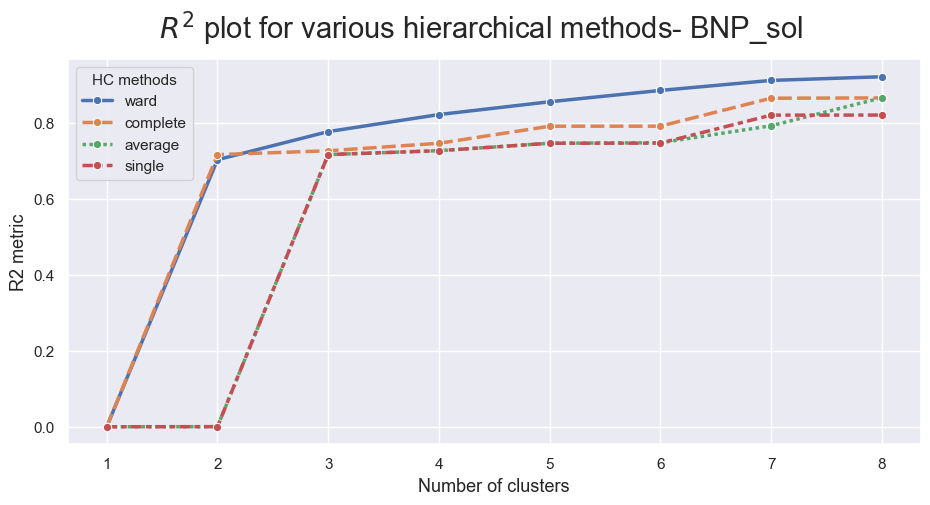

In [ ]:
r2_hc_methods_sol = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods_sol)

sns.set()

# plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods_sol, linewidth=2.5, markers=["o"]*4)

# finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods- BNP_sol", fontsize=21)

plt.show()

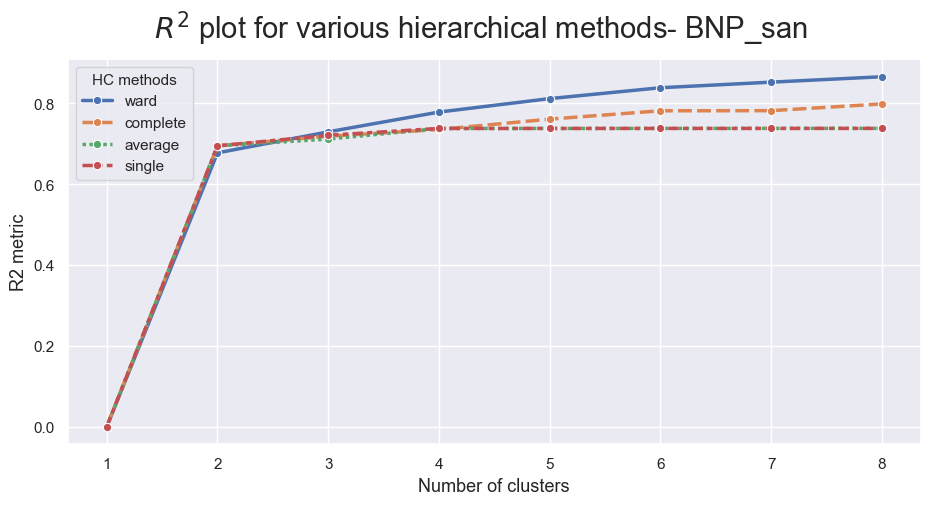

In [ ]:
r2_hc_methods_san = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods_san)

sns.set()

# plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods_san, linewidth=2.5, markers=["o"]*4)

# finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods- BNP_san", fontsize=21)

plt.show()

In [ ]:
#settig the best method
linkage_matrix_sol= linkage(final_data_sol, method="ward")

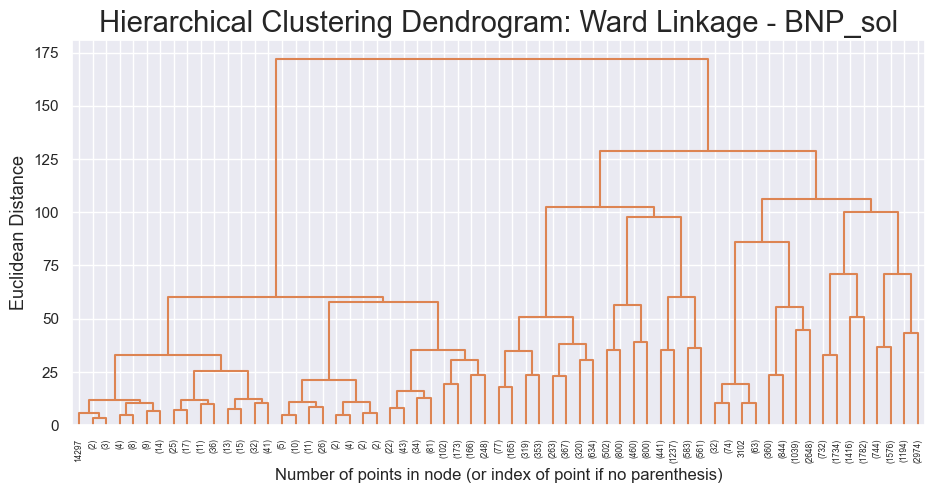

In [ ]:
# plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
Y_THRESHOLD = 110
dendrogram(linkage_matrix_sol, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')

plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage - BNP_sol', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Euclidean Distance', fontsize=13)
plt.show()

In [ ]:
# 2 clusters

n_clusters = 2

hc2_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc2_labels_sol = hc2_clust_sol.fit_predict(final_data_sol)

df_concat_2_sol = pd.concat([final_data_sol, 
                       pd.Series(hc2_labels_sol, 
                                 name='labels', 
                                 index=final_data_sol.index)], 
                    axis=1)

df_concat_2_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.084266,-0.157806,0.485292,0.070133,0.177360,0.120896,0.036528,0.063844
1,1.324727,-0.284855,0.508321,3.472461,0.634268,0.205374,0.032476,0.108338


In [ ]:
# 3 clusters

n_clusters = 3

hc3_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc3_labels_sol = hc3_clust_sol.fit_predict(final_data_sol)

df_concat_3_sol = pd.concat([final_data_sol, 
                       pd.Series(hc3_labels_sol, 
                                 name='labels', 
                                 index=final_data_sol.index)], 
                    axis=1)

df_concat_3_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,-0.091704,-0.096535,0.450085,-0.221519,0.005690,0.129133,0.034664,0.092930
1,1.324727,-0.284855,0.508321,3.472461,0.634268,0.205374,0.032476,0.108338
2,0.468557,-0.291612,0.562179,0.707054,0.552262,0.102908,0.040600,0.000324


In [ ]:
# 4 clusters

n_clusters = 4

hc4_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc4_labels_sol = hc4_clust_sol.fit_predict(final_data_sol)

df_concat_4_sol = pd.concat([final_data_sol, 
                       pd.Series(hc4_labels_sol, 
                                 name='labels', 
                                 index=final_data_sol.index)], 
                    axis=1)

df_concat_4_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,RESSO,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,,
0,0.134351,-0.162261,0.189565,0.491662,0.211348,0.199894,0.123661,0.037111,0.042540
1,0.279429,-0.196968,5.073844,0.332227,0.492571,0.130945,0.153179,0.014331,0.738159
2,0.166667,-0.305556,197.065870,0.000000,0.000000,0.000000,0.000000,0.000000,1.444444
3,-0.500000,-0.305556,923.613542,0.000000,0.000000,0.000000,0.000000,0.000000,1.055556


In [ ]:
#checking the mumber of observations in each cluster
pd.crosstab(
    pd.Series(hc2_labels_sol, name='hc2_labels_sol', index=final_data_sol.index),
    pd.Series(hc3_labels_sol, name='hc3_labels_sol', index=final_data_sol.index),
    )

hc3_labels_sol,0,1,2
hc2_labels_sol,,,
0,17213,0,7882
1,0,1162,0


In [ ]:
pd.crosstab(
    pd.Series(hc3_labels_sol, name='hc2_labels_sol', index=final_data_sol.index),
    pd.Series(hc4_labels_sol, name='hc3_labels_sol', index=final_data_sol.index),
    )

hc3_labels_sol,0,1,2,3
hc2_labels_sol,,,,
0,16697,514,1,1
1,1067,95,0,0
2,7616,266,0,0


In [ ]:
#settig the best method
linkage_matrix_san= linkage(final_data_san, method="ward")

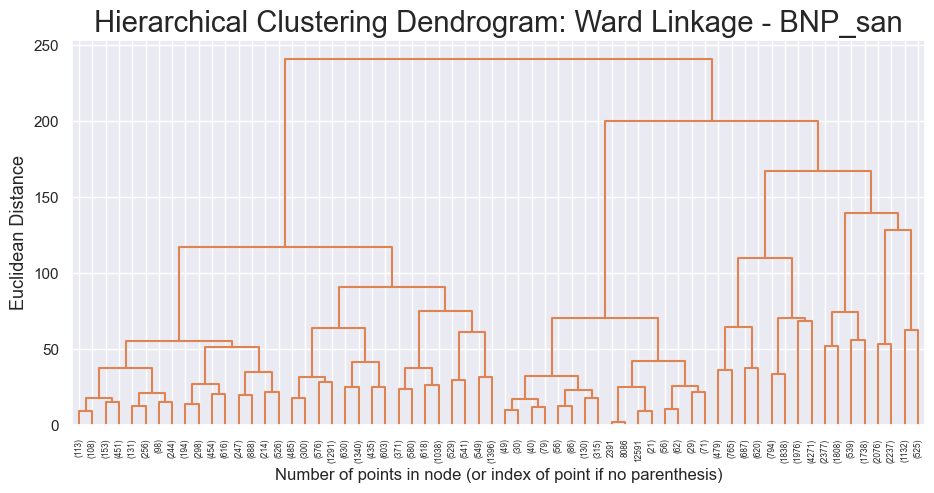

In [ ]:
# plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
Y_THRESHOLD = 150
dendrogram(linkage_matrix_san, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')

plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage - BNP_san', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Euclidean Distance', fontsize=13)
plt.show()

In [ ]:
# 2 clusters

n_clusters = 2

hc2_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc2_labels_san = hc2_clust_san.fit_predict(final_data_san)

df_concat_2_san = pd.concat([final_data_san, 
                       pd.Series(hc2_labels_san, 
                                 name='labels', 
                                 index=final_data_san.index)], 
                    axis=1)

df_concat_2_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.431184,-0.091549,0.572926,1.265298,0.409696,0.294126,0.032460,0.049447
1,-0.048170,-0.629832,0.437568,-0.197075,0.103086,-0.133353,0.040877,0.016865


In [ ]:
# 2 clusters

n_clusters = 3

hc3_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc3_labels_san = hc3_clust_san.fit_predict(final_data_san)

df_concat_3_san = pd.concat([final_data_san, 
                       pd.Series(hc3_labels_san, 
                                 name='labels', 
                                 index=final_data_san.index)], 
                    axis=1)

df_concat_3_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.423031,-0.081527,0.575833,1.080085,0.407617,0.304716,0.032883,0.045485
1,-0.048170,-0.629832,0.437568,-0.197075,0.103086,-0.133353,0.040877,0.016865
2,0.620618,-0.324409,0.505383,5.568647,0.458003,0.048076,0.022620,0.141492


In [ ]:
# 4 clusters

n_clusters = 4

hc4_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc4_labels_san = hc4_clust_san.fit_predict(final_data_san)

df_concat_4_san = pd.concat([final_data_san, 
                       pd.Series(hc4_labels_san, 
                                 name='labels', 
                                 index=final_data_san.index)], 
                    axis=1)

df_concat_4_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.558468,0.211071,0.582050,0.502252,0.600905,0.558362,0.034713,0.041988
1,-0.048170,-0.629832,0.437568,-0.197075,0.103086,-0.133353,0.040877,0.016865
2,0.620618,-0.324409,0.505383,5.568647,0.458003,0.048076,0.022620,0.141492
3,0.275722,-0.399775,0.569072,1.708574,0.197384,0.028835,0.030893,0.049289


In [ ]:
#checking the mumber of observations in each cluster
pd.crosstab(
    pd.Series(hc2_labels_san, name='hc2_labels_san', index=final_data_san.index),
    pd.Series(hc3_labels_san, name='hc3_labels_san', index=final_data_san.index),
    )

hc3_labels_san,0,1,2
hc2_labels_san,,,
0,23862,0,1027
1,0,16273,0


In [ ]:
pd.crosstab(
    pd.Series(hc3_labels_san, name='hc3_labels_san', index=final_data_san.index),
    pd.Series(hc4_labels_san, name='hc4_labels_san', index=final_data_san.index),
    )

hc4_labels_san,0,1,2,3
hc3_labels_san,,,,
0,12432,0,0,11430
1,0,16273,0,0
2,0,0,1027,0


##### 5.2.2. K-Means

In [ ]:
range_clusters_sol = range(1, 9)

inertia = []
for n_clus in range_clusters_sol:  # iterate over desired ncluster range
    kmclust_sol = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust_sol.fit(final_data_sol)
    inertia.append(kmclust_sol.inertia_) 

In [ ]:
range_clusters_san = range(1, 9)

inertia = []
for n_clus in range_clusters_san:  # iterate over desired ncluster range
    kmclust_san = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust_san.fit(final_data_san)
    inertia.append(kmclust_san.inertia_) 

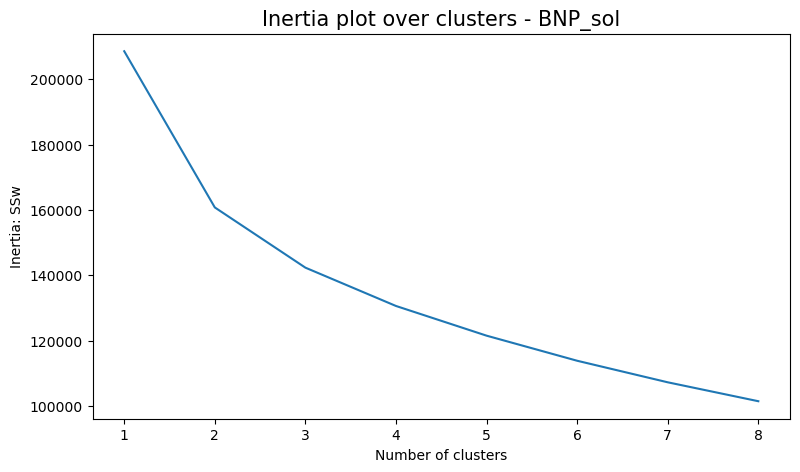

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters_sol, inertia)
ax.set_xticks(range_clusters_sol)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters - BNP_sol", size=15)

plt.show()

In [ ]:
avg_silhouette_sol = []

for nclus in range_clusters_sol:
    if nclus == 1:
        continue

    kmclust_sol = KMeans(
        n_clusters=nclus,
        init='k-means++',
        n_init=15,
        random_state=1
    )

    cluster_labels_sol = kmclust_sol.fit_predict(final_data_sol)

    silhouette_avg_sol = silhouette_score(final_data_sol, cluster_labels_sol)
    avg_silhouette_sol.append(silhouette_avg_sol)

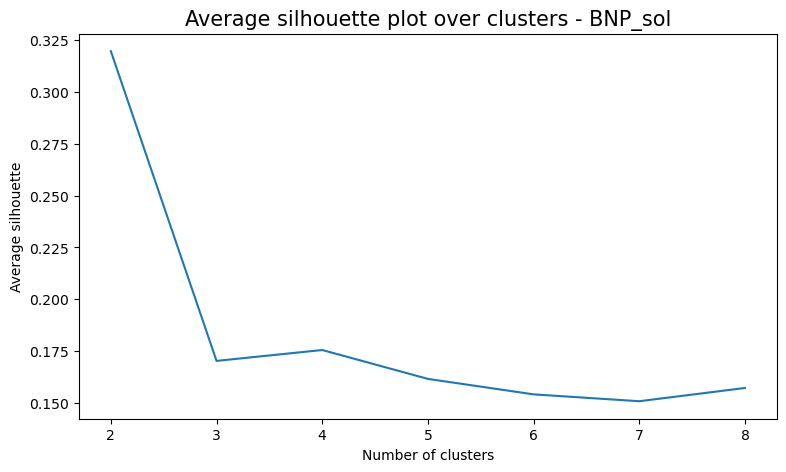

In [ ]:
# average silhouette plot
# inertia plot
plt.figure(figsize=(9,5))

plt.plot(range_clusters_sol[1:],
         avg_silhouette_sol)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters - BNP_sol", size=15)
plt.show()

In [ ]:
# 2 clusters
number_clusters = 2
kmclust2_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels2_sol = kmclust2_sol.fit_predict(final_data_sol)
km_labels2_sol

array([1, 1, 1, ..., 0, 0, 1], dtype=int32)

In [ ]:
df_concat_km2_sol = pd.concat((final_data_sol, pd.Series(km_labels2_sol, name='labels', index=final_data_sol.index)), axis=1)
df_concat_km2_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.908671,-0.220879,0.542544,2.060993,0.511909,0.234997,0.036547,0.000670
1,-0.005209,-0.152650,0.475761,-0.124565,0.138608,0.103929,0.036312,0.078035


In [ ]:
# 3 clusters
number_clusters = 3
kmclust3_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels3_sol = kmclust3_sol.fit_predict(final_data_sol)
km_labels3_sol

c:\Users\nicol\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\nicol\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\nicol\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nicol\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

array([2, 1, 2, ..., 0, 0, 2], dtype=int32)

In [ ]:
df_concat_km3_sol = pd.concat((final_data_sol, pd.Series(km_labels3_sol, name='labels', index=final_data_sol.index)), axis=1)
df_concat_km3_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.880847,-0.243274,0.536800,2.531676,0.511803,0.196827,0.036246,-0.003387
1,0.150097,0.342761,0.518087,-0.063332,0.169652,0.665597,0.025044,0.312820
2,-0.046921,-0.594343,0.446063,-0.076375,0.147685,-0.373338,0.046421,-0.137271


In [ ]:
# 3 clusters
number_clusters = 4
kmclust4_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels4_sol = kmclust4_sol.fit_predict(final_data_sol)
km_labels4_sol

array([1, 2, 1, ..., 0, 0, 1], dtype=int32)

In [ ]:
df_concat_km4_sol = pd.concat((final_data_sol, pd.Series(km_labels4_sol, name='labels', index=final_data_sol.index)), axis=1)
df_concat_km4_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,1.593329,-0.174681,0.475551,0.202730,0.293409,0.226660,0.033321,0.258705
1,-0.165415,-0.600106,0.442523,-0.081372,0.140866,-0.397265,0.047608,-0.160130
2,-0.126979,0.369625,0.528995,-0.083174,0.161407,0.683741,0.024009,0.279588
3,0.500000,-0.223287,0.536822,2.852273,0.465390,0.193942,0.037152,-0.007950


In [ ]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels2_sol, name='km_labels2_sol', index=final_data_sol.index),
    pd.Series(km_labels4_sol, name='km_labels4_sol', index=final_data_sol.index),
    )

km_labels4_sol,0,1,2,3
km_labels2_sol,,,,
0,1210,286,276,2376
1,2233,10762,9114,0


In [ ]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels2_sol, name='km_labels2_sol', index=final_data_sol.index),
    pd.Series(km_labels3_sol, name='km_labels3_sol', index=final_data_sol.index),
    )

km_labels3_sol,0,1,2
km_labels2_sol,,,
0,2936,693,519
1,0,10281,11828


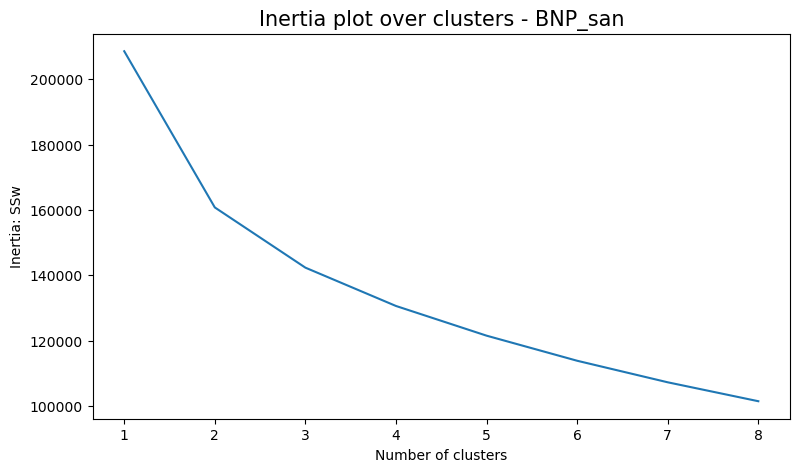

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters_san, inertia)
ax.set_xticks(range_clusters_san)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters - BNP_san", size=15)

plt.show()

In [ ]:
avg_silhouette_san = []

for nclus in range_clusters_san:
    if nclus == 1:
        continue

    kmclust_san = KMeans(
        n_clusters=nclus,
        init='k-means++',
        n_init=15,
        random_state=1
    )

    cluster_labels_san = kmclust_san.fit_predict(final_data_san)

    silhouette_avg = silhouette_score(final_data_san, cluster_labels_san)
    avg_silhouette_san.append(silhouette_avg)

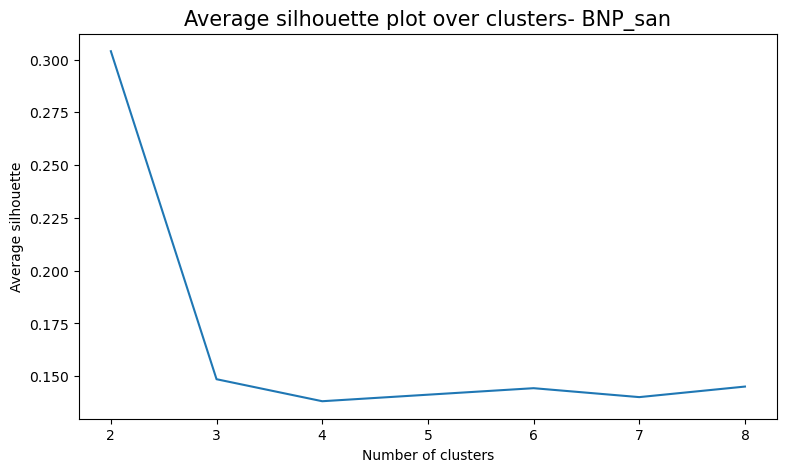

In [ ]:
# average silhouette plot
# inertia plot
plt.figure(figsize=(9,5))

plt.plot(range_clusters_san[1:],
         avg_silhouette_san)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters- BNP_san", size=15)
plt.show()

In [ ]:
# 2 clusters
number_clusters = 2
kmclust2_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels2_san = kmclust2_san.fit_predict(final_data_san)
km_labels2_san

array([0, 0, 1, ..., 0, 0, 0], dtype=int32)

In [ ]:
df_concat_km2_san = pd.concat((final_data_san, pd.Series(km_labels2_san, name='labels', index=final_data_san.index)), axis=1)
df_concat_km2_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.134568,-0.323096,0.516153,0.163983,0.238134,0.12071,0.037539,0.020185
1,0.672945,-0.228889,0.532542,2.793748,0.491201,0.14291,0.028735,0.102523


In [ ]:
# 3 clusters
number_clusters = 3
kmclust3_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels3_san = kmclust3_san.fit_predict(final_data_san)
km_labels3_san

array([2, 1, 0, ..., 1, 1, 1], dtype=int32)

In [ ]:
df_concat_km3_san = pd.concat((final_data_san, pd.Series(km_labels3_san, name='labels', index=final_data_san.index)), axis=1)
df_concat_km3_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.634847,-0.218450,0.535367,2.852518,0.486142,0.141507,0.028271,0.111608
1,0.421378,0.177923,0.556623,0.225523,0.273249,0.581791,0.030216,0.252166
2,-0.107298,-0.797772,0.477081,0.131884,0.212454,-0.312387,0.044471,-0.200766


In [ ]:
# 3 clusters
number_clusters = 4
kmclust4_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels4_san = kmclust4_san.fit_predict(final_data_san)
km_labels4_san

array([1, 1, 3, ..., 3, 3, 1], dtype=int32)

In [ ]:
df_concat_km4_san = pd.concat((final_data_san, pd.Series(km_labels4_san, name='labels', index=final_data_san.index)), axis=1)
df_concat_km4_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,-0.144670,-0.922854,0.461670,0.000223,0.181308,-0.342269,0.046425,-0.217747
1,0.162774,0.238905,0.574081,-0.101379,0.171447,0.656943,0.031774,0.216459
2,0.763447,-0.214107,0.543089,3.925703,0.558993,0.160047,0.026568,0.136976
3,0.608386,-0.193601,0.521182,1.333923,0.452051,0.092712,0.030601,0.108660


In [ ]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels4_san, name='km_labels4_san', index=final_data_san.index),
    pd.Series(km_labels3_san, name='km_labels3_san', index=final_data_san.index),
    )

km_labels3_san,0,1,2
km_labels4_san,,,
0,0,104,13362
1,0,11186,1144
2,3486,0,0
3,4359,4868,2653


In [ ]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels2_san, name='km_labels2_san', index=final_data_san.index),
    pd.Series(km_labels3_san, name='km_labels3_san', index=final_data_san.index),
    )

km_labels3_san,0,1,2
km_labels2_san,,,
0,1,15949,17023
1,7844,209,136


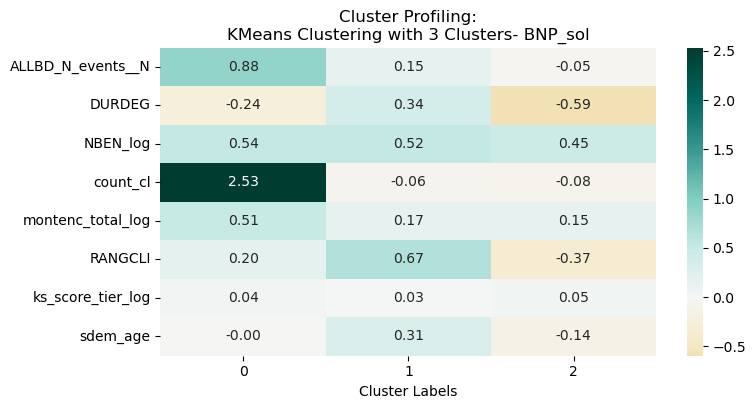

In [ ]:
#visualization of averages for 2 clusters
fig, ax = plt.subplots(figsize=(8,4))

km_profile3_sol = df_concat_km3_sol.groupby('labels').mean().T

sns.heatmap(km_profile3_sol,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 3 Clusters- BNP_sol")
plt.show()

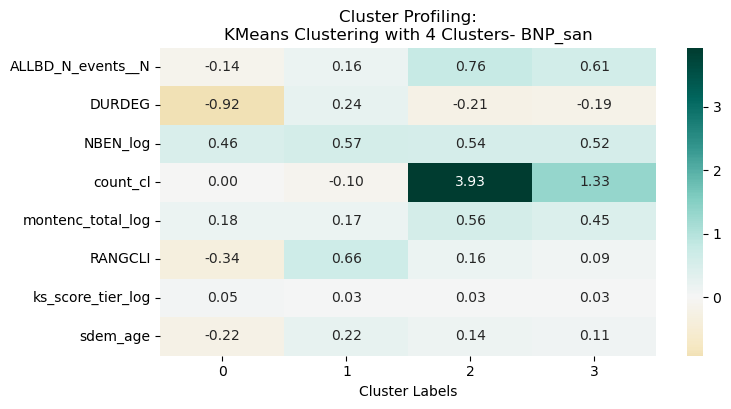

In [ ]:
#visualization of averages for 2 clusters
fig, ax = plt.subplots(figsize=(8,4))

km_profile4_san = df_concat_km4_san.groupby('labels').mean().T

sns.heatmap(km_profile4_san,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 4 Clusters- BNP_san")
plt.show()

## 6. Results and Profiling

#### 6.1. Results

In [ ]:
BNP_sol['km_labels3_sol'] = km_labels3_sol
BNP_san['km_labels4_san'] = km_labels4_san

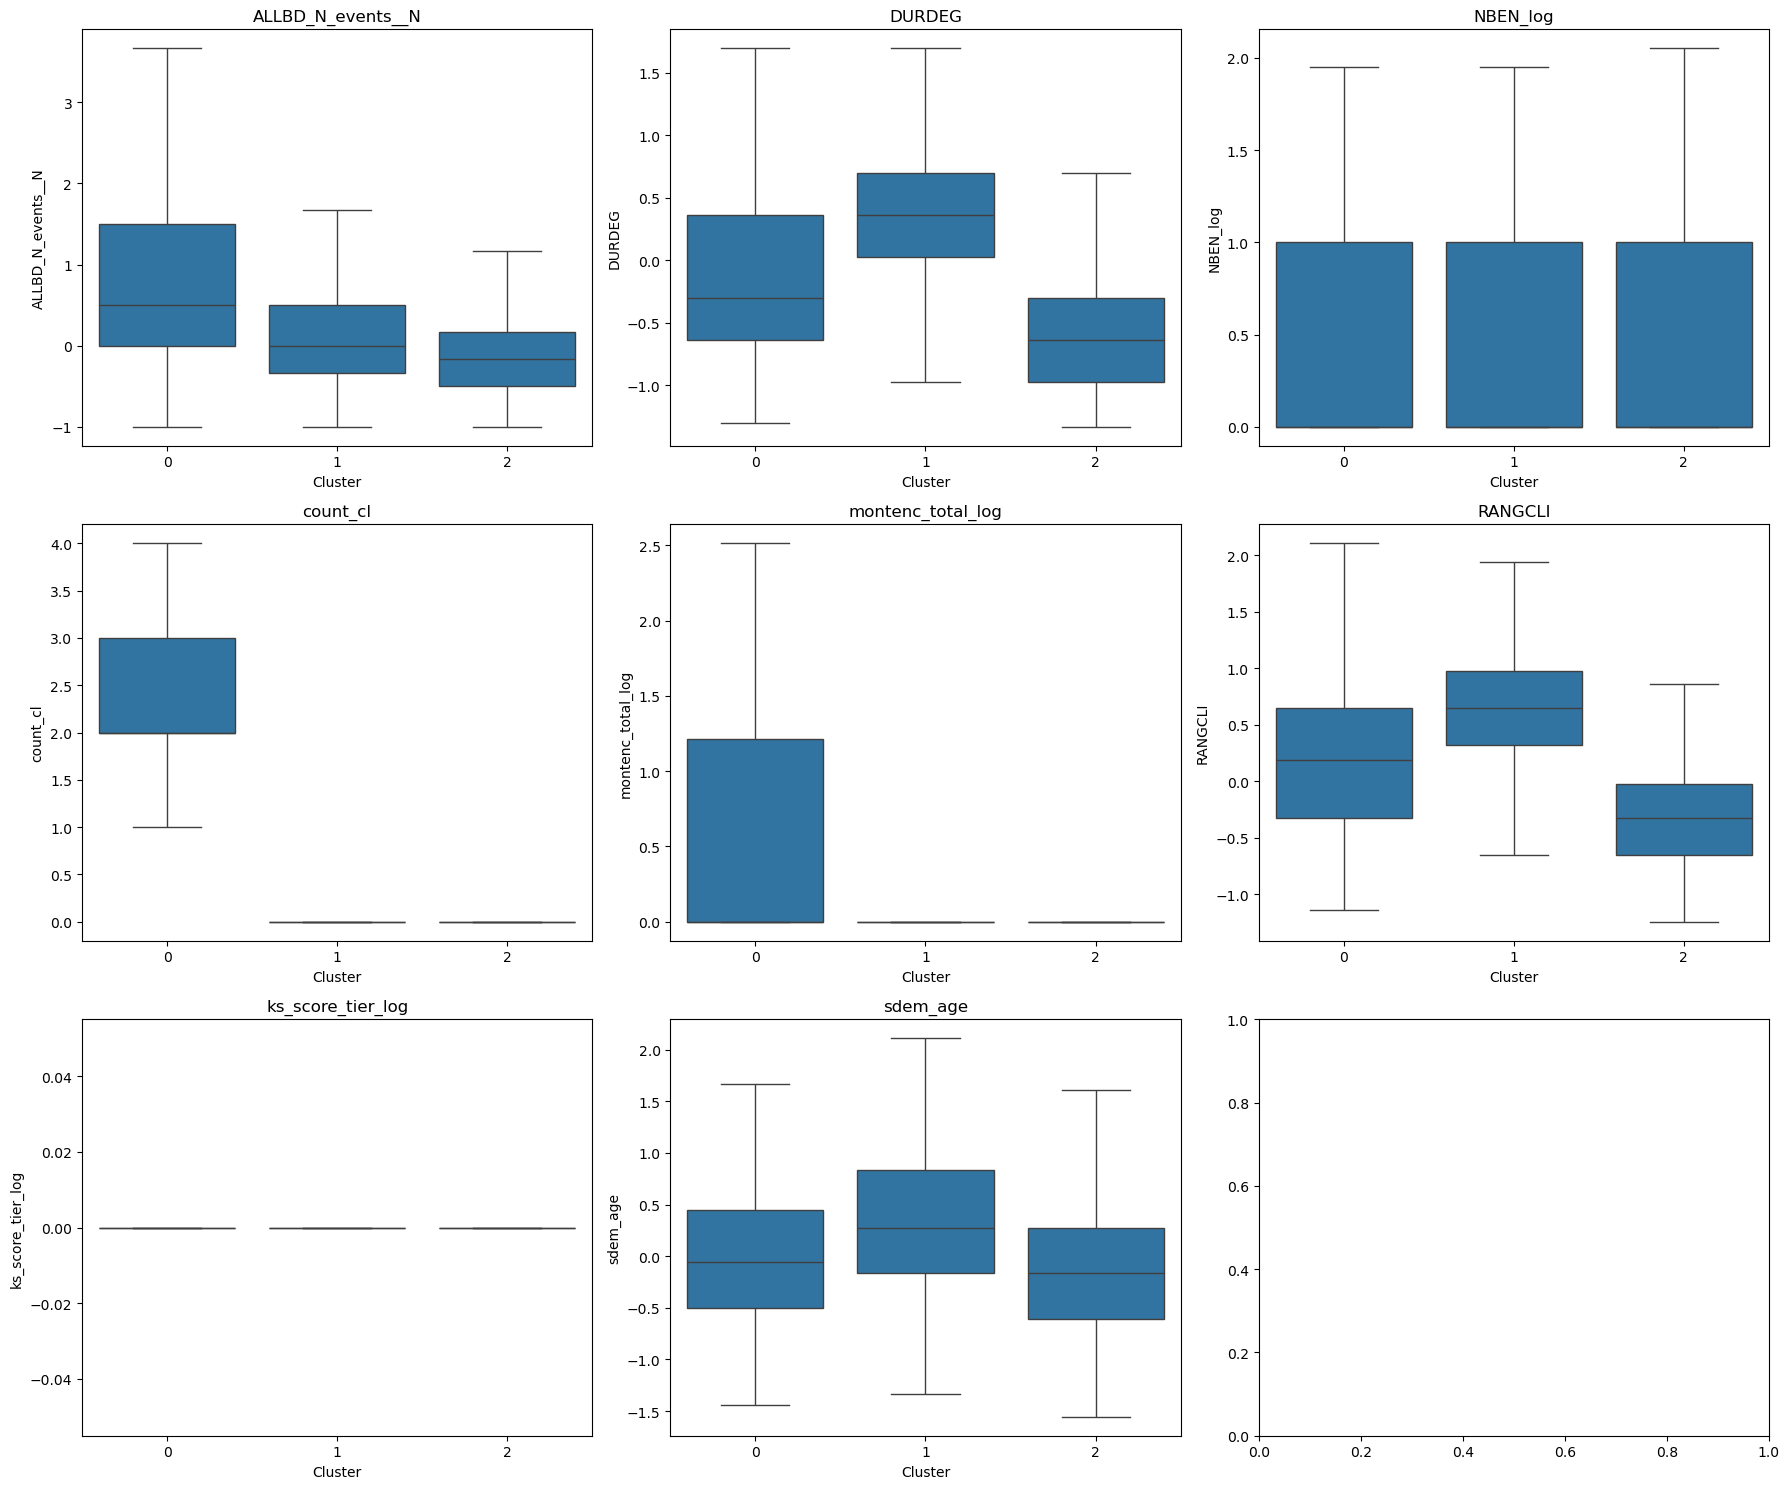

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ax, var in zip(axes.flatten(), final_features):
    sns.boxplot(
        data=BNP_sol,
        x="km_labels3_sol",
        y=var,
        ax=ax,
        showfliers=False
    )
    ax.set_title(var)
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

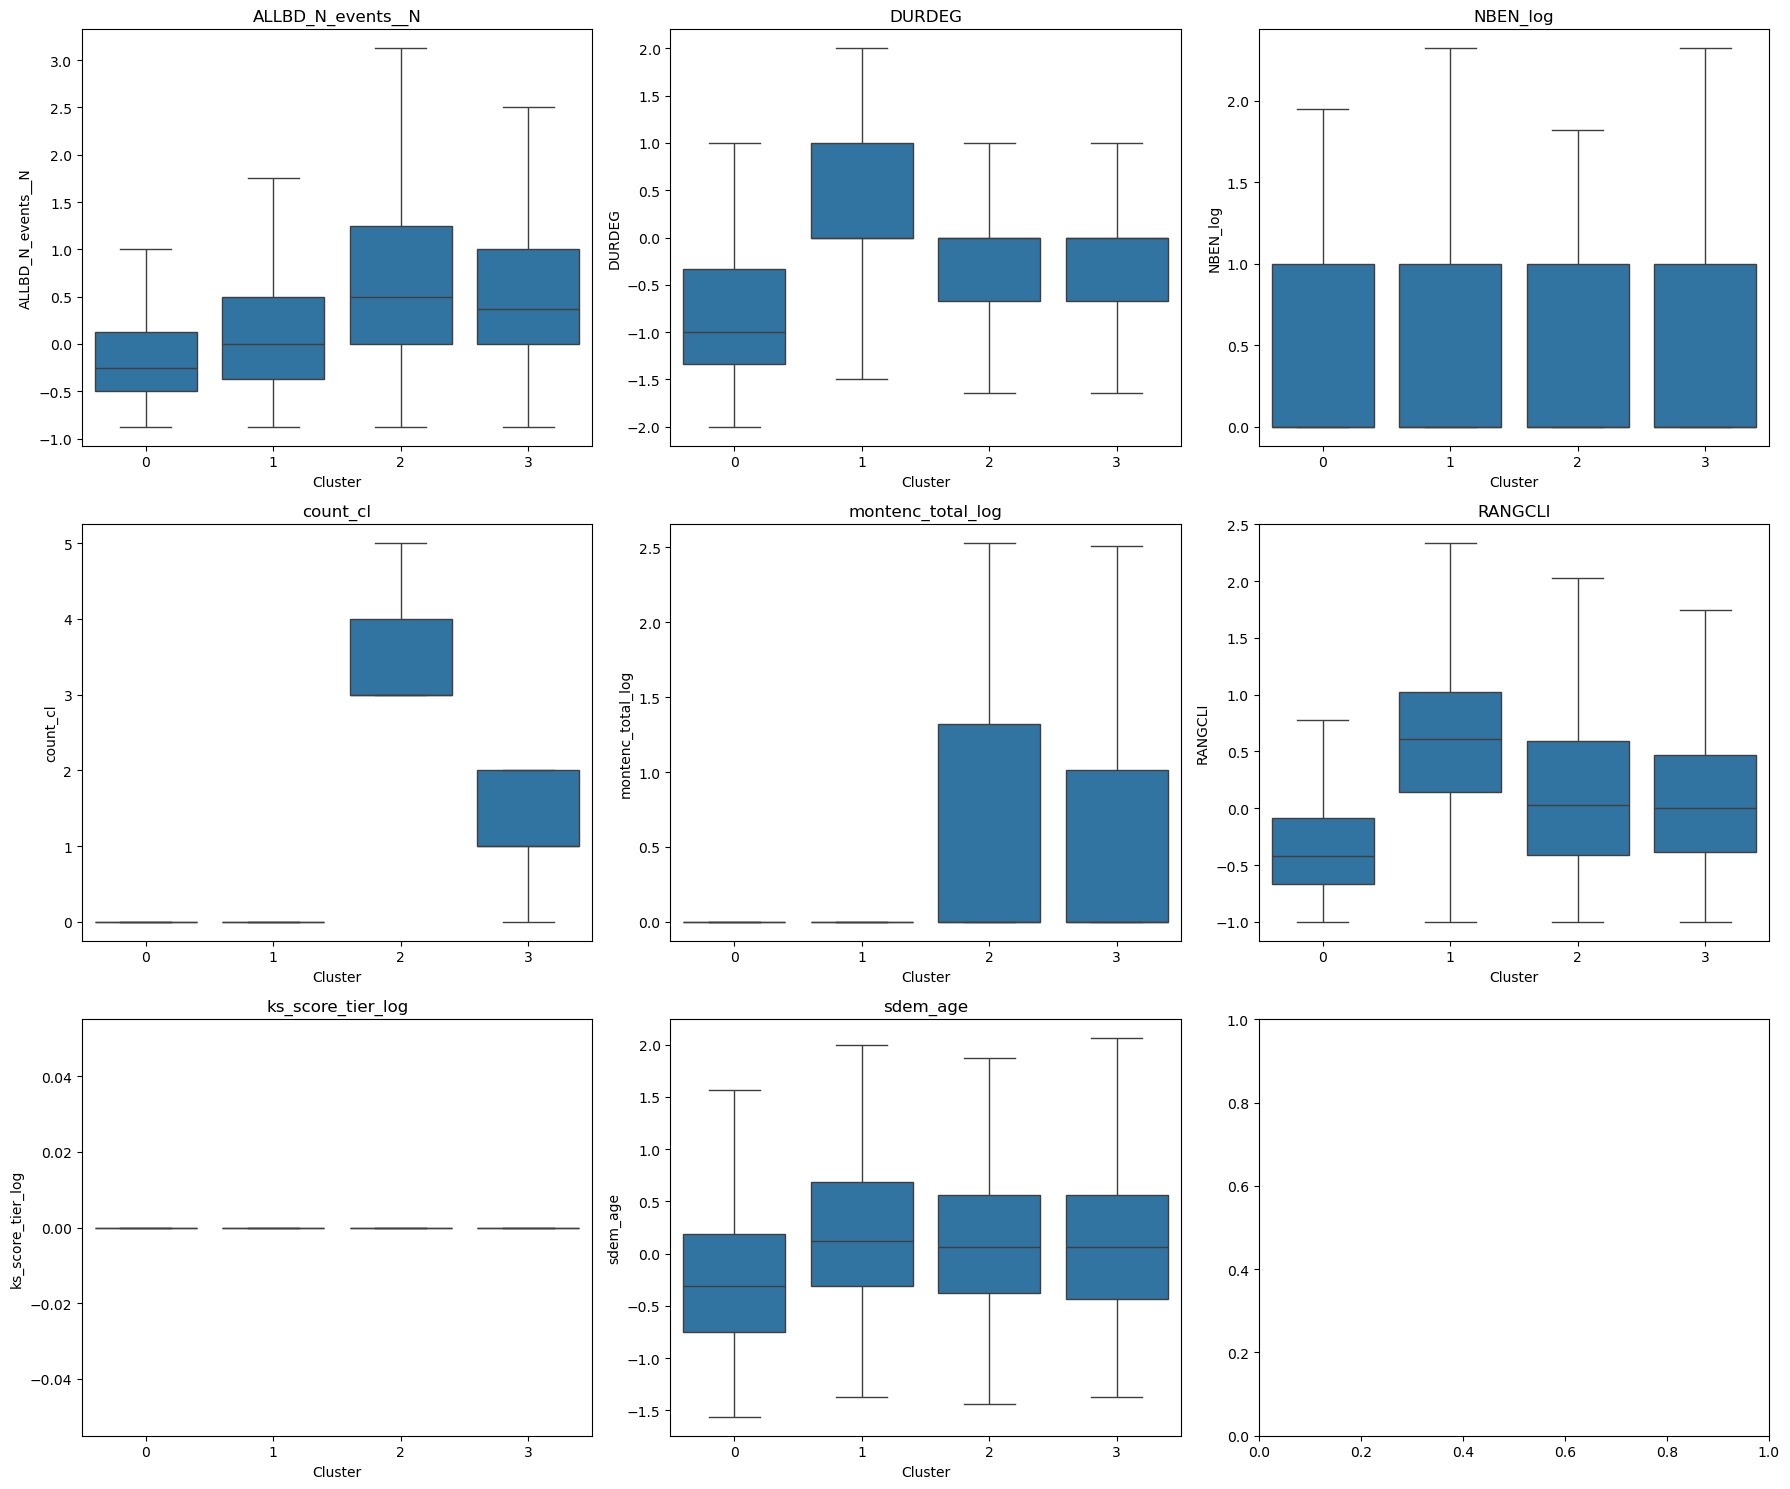

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ax, var in zip(axes.flatten(), final_features):
    sns.boxplot(
        data=BNP_san,
        x="km_labels4_san",
        y=var,
        ax=ax,
        showfliers=False
    )
    ax.set_title(var)
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

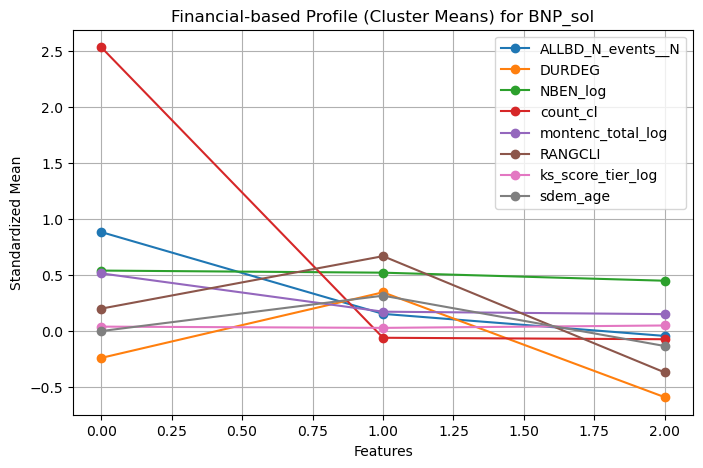

In [ ]:
final_means_sol = BNP_sol.groupby("km_labels3_sol")[final_features].mean()

# normalizar para visualização
# value_means_norm = (value_means - value_means.mean()) / value_means.std()

final_means_sol.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Financial-based Profile (Cluster Means) for BNP_sol")
plt.ylabel("Standardized Mean")
plt.xlabel("Features")
plt.grid(True)
plt.show()

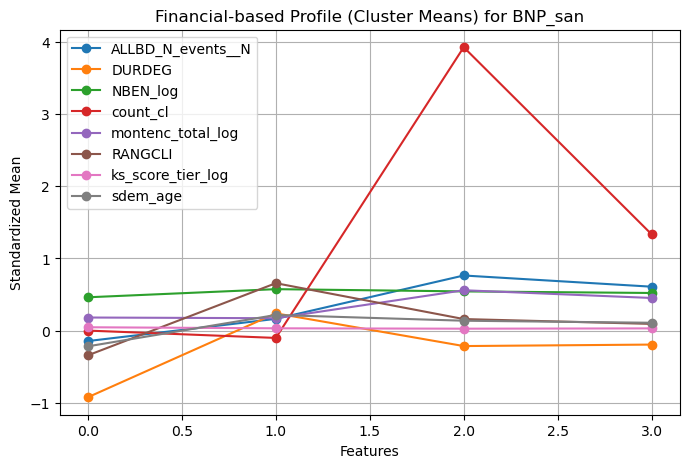

In [ ]:
final_means_san = BNP_san.groupby("km_labels4_san")[final_features].mean()

# normalizar para visualização
# value_means_norm = (value_means - value_means.mean()) / value_means.std()

final_means_san.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Financial-based Profile (Cluster Means) for BNP_san")
plt.ylabel("Standardized Mean")
plt.xlabel("Features")
plt.grid(True)
plt.show()

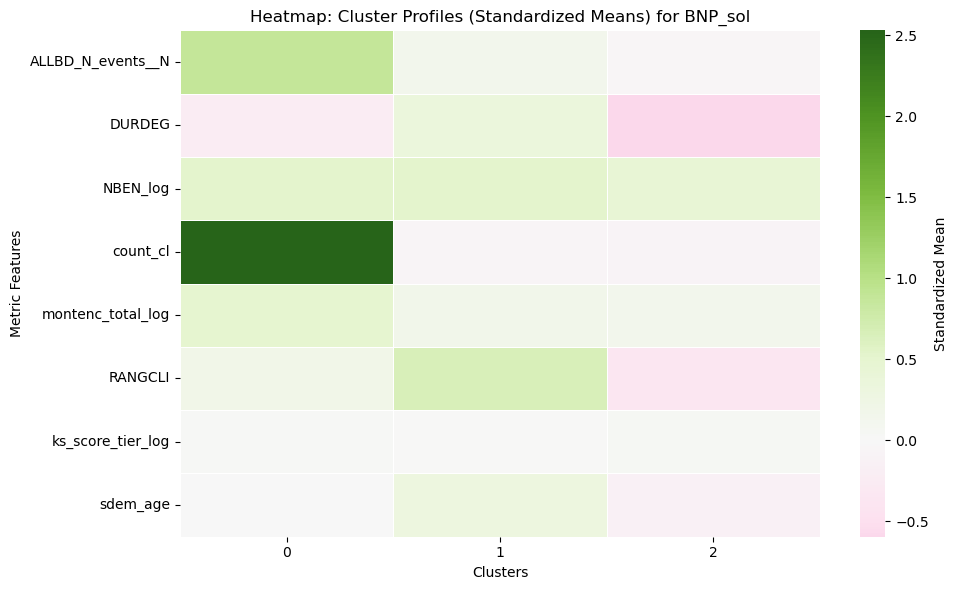

In [ ]:
cluster_col_sol = "km_labels3_sol"  # ou "merged_labels"

cluster_means_sol = BNP_sol.groupby(cluster_col_sol)[final_features].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_means_sol.T,   # transposto: features nas linhas
    cmap="PiYG",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Mean"}
)

plt.title("Heatmap: Cluster Profiles (Standardized Means) for BNP_sol")
plt.xlabel("Clusters")
plt.ylabel("Metric Features")
plt.tight_layout()
plt.show()

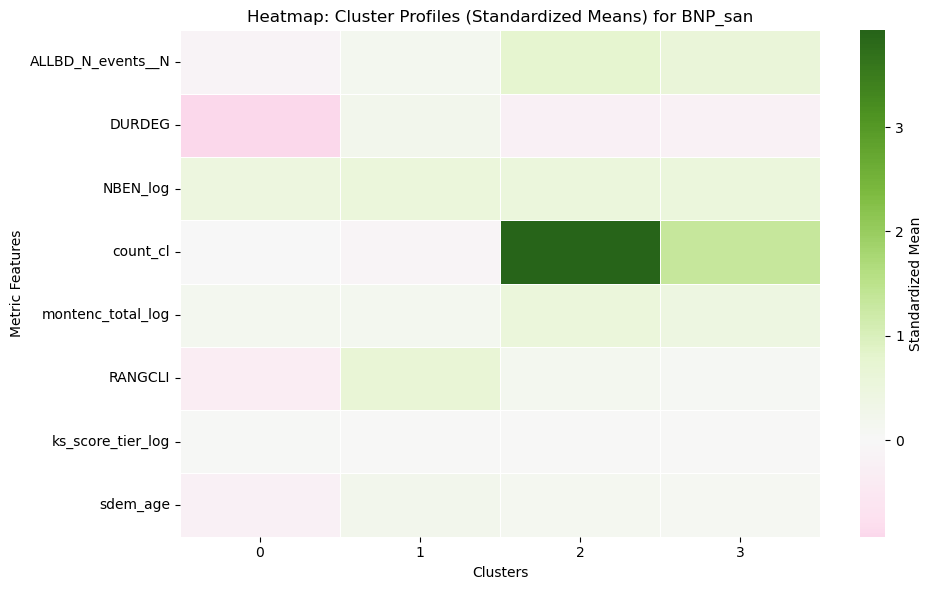

In [ ]:
cluster_col_san = "km_labels4_san"  # ou "merged_labels"

cluster_means_san = BNP_san.groupby(cluster_col_san)[final_features].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_means_san.T,   # transposto: features nas linhas
    cmap="PiYG",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Mean"}
)

plt.title("Heatmap: Cluster Profiles (Standardized Means) for BNP_san")
plt.xlabel("Clusters")
plt.ylabel("Metric Features")
plt.tight_layout()
plt.show()

#### 6.2. Profiling

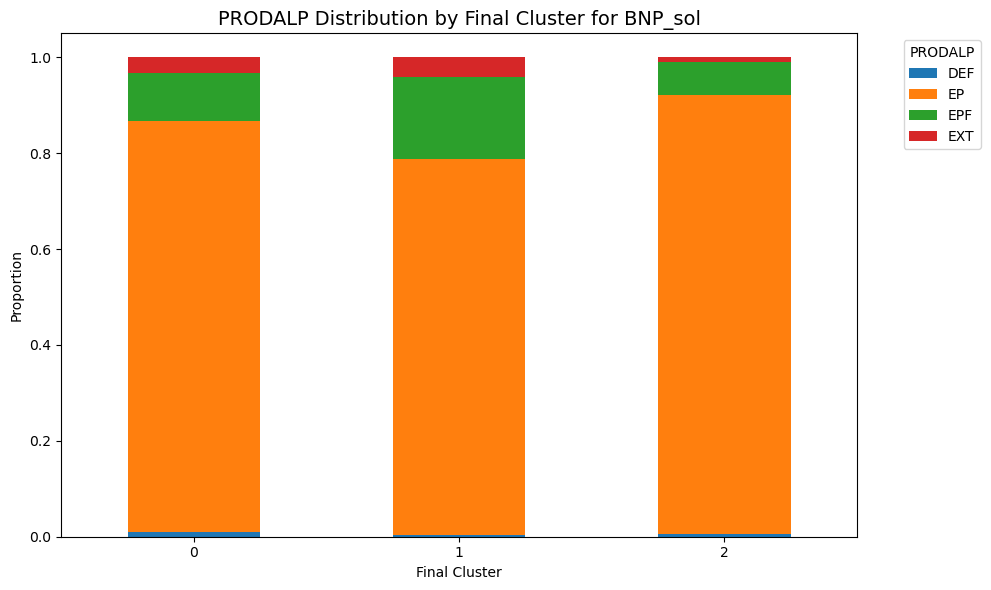

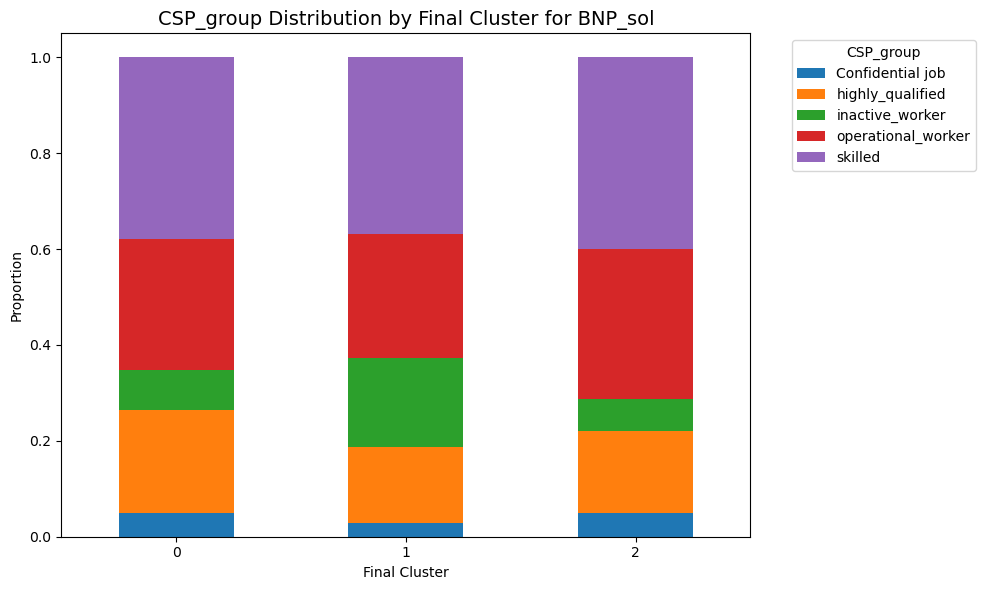

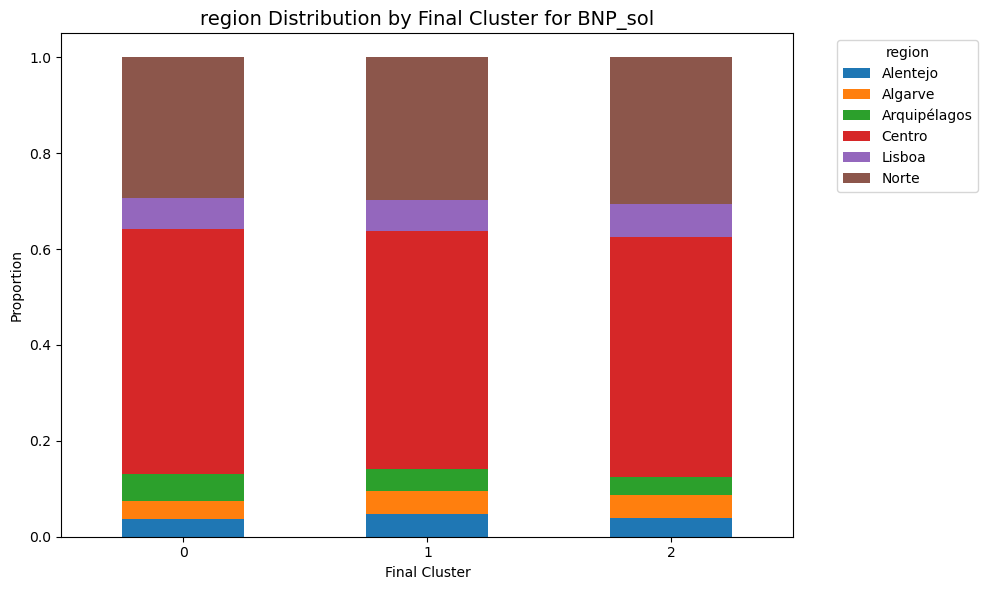

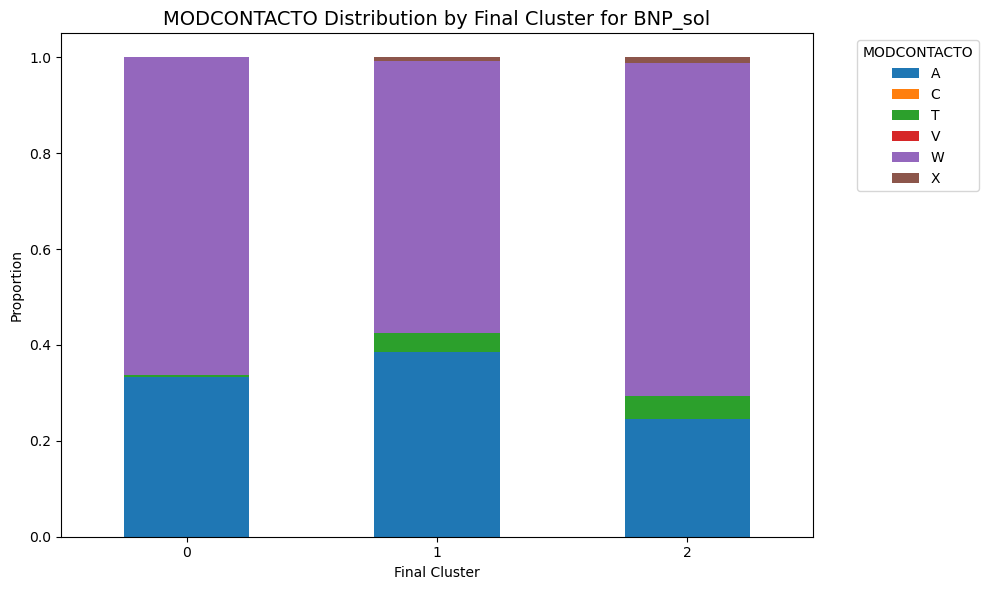

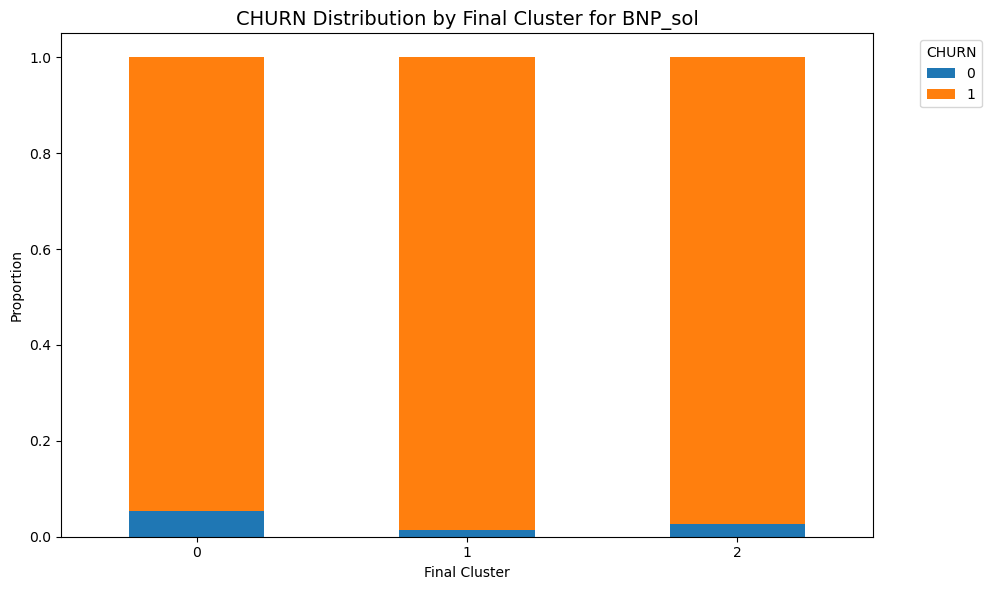

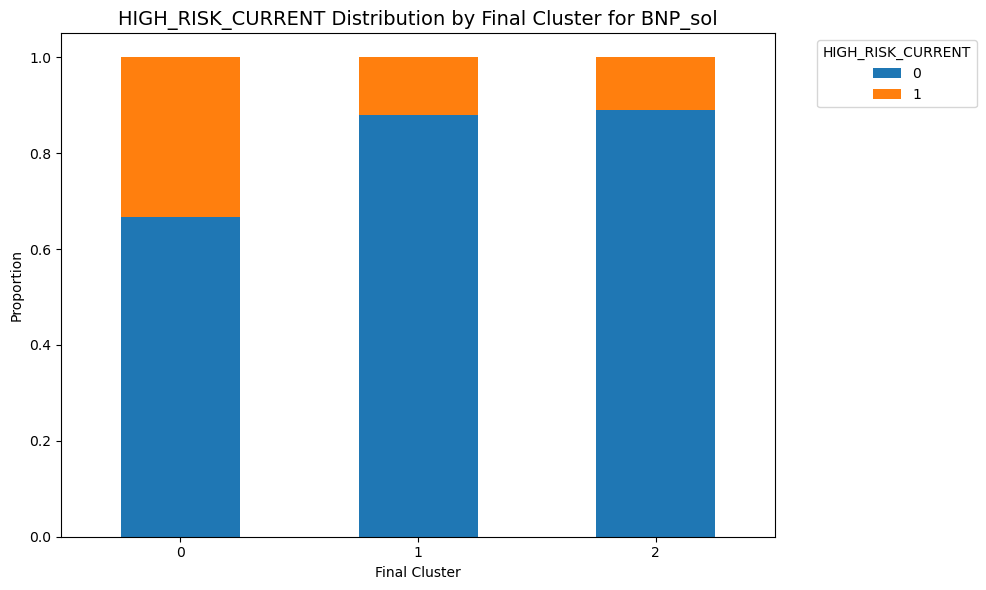

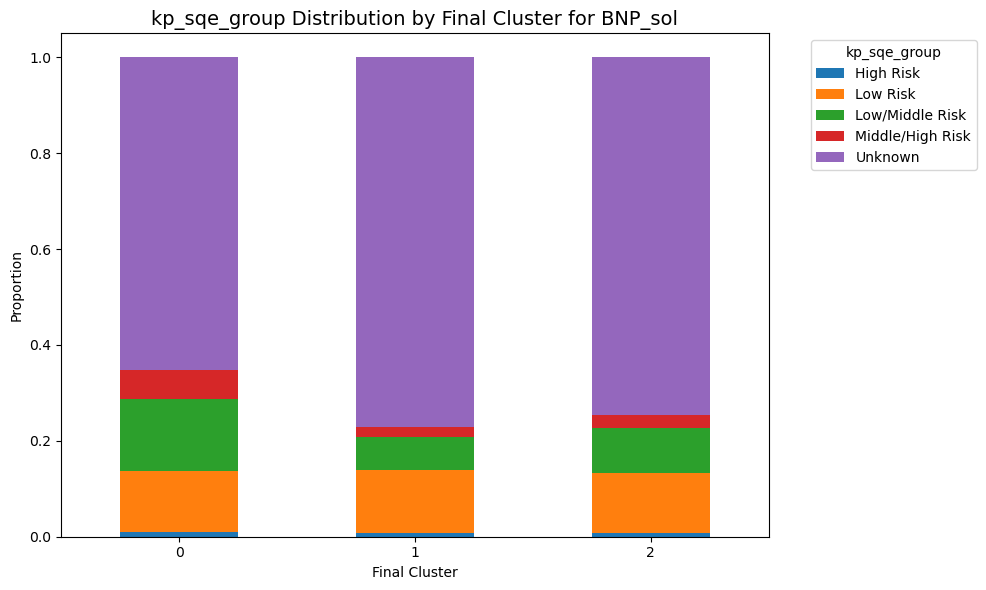

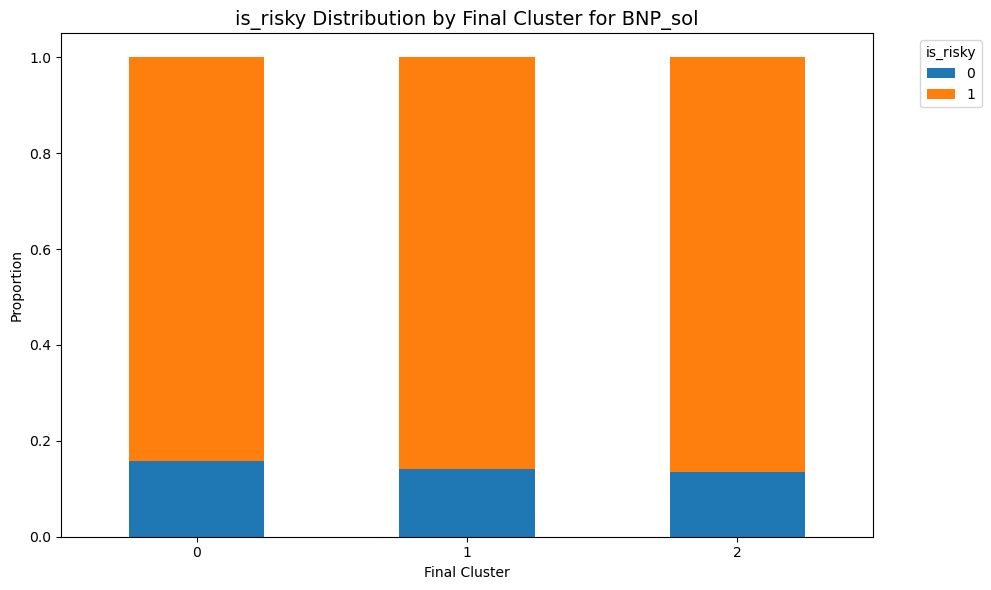

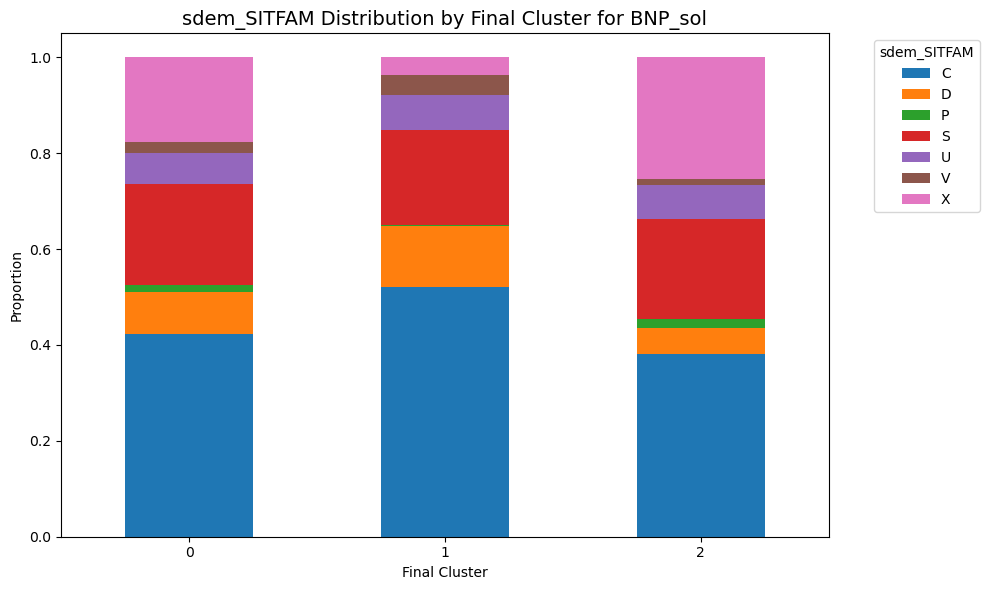

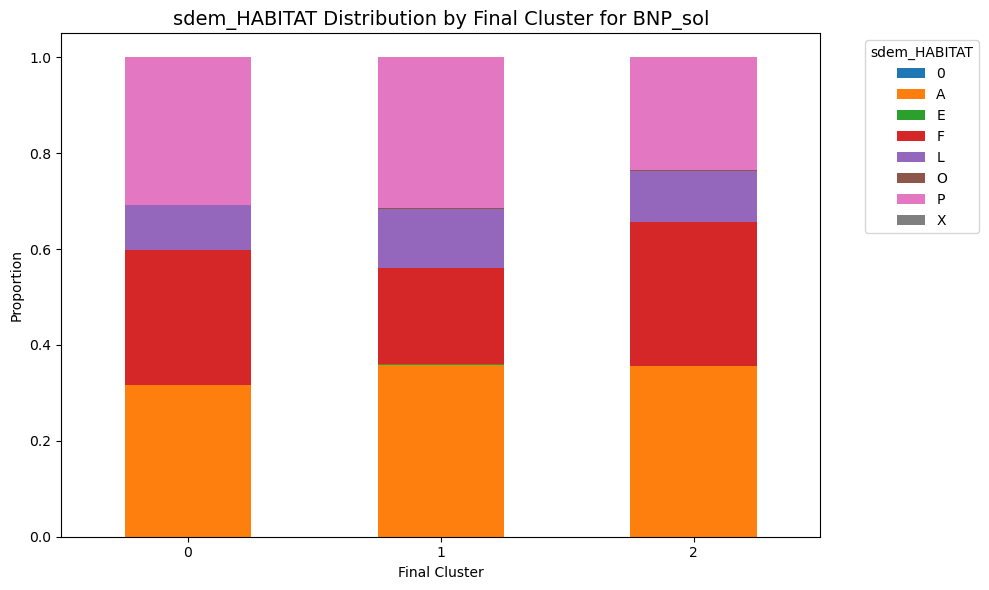

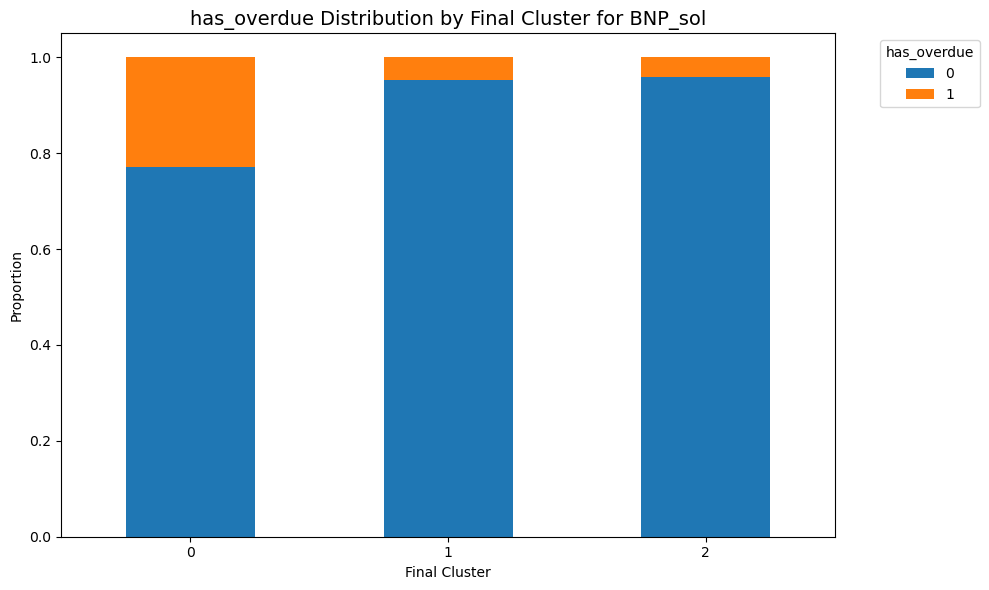

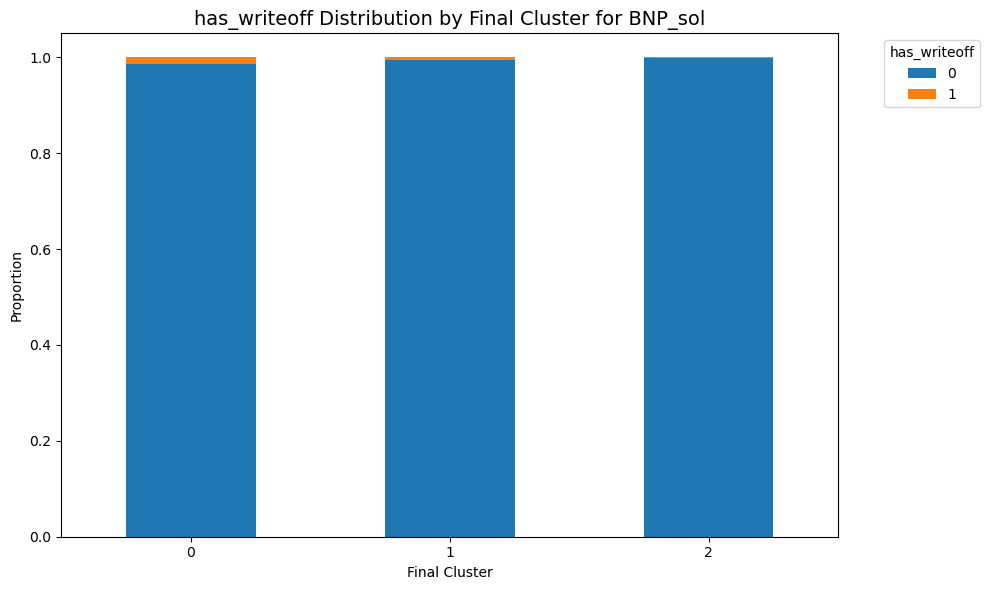

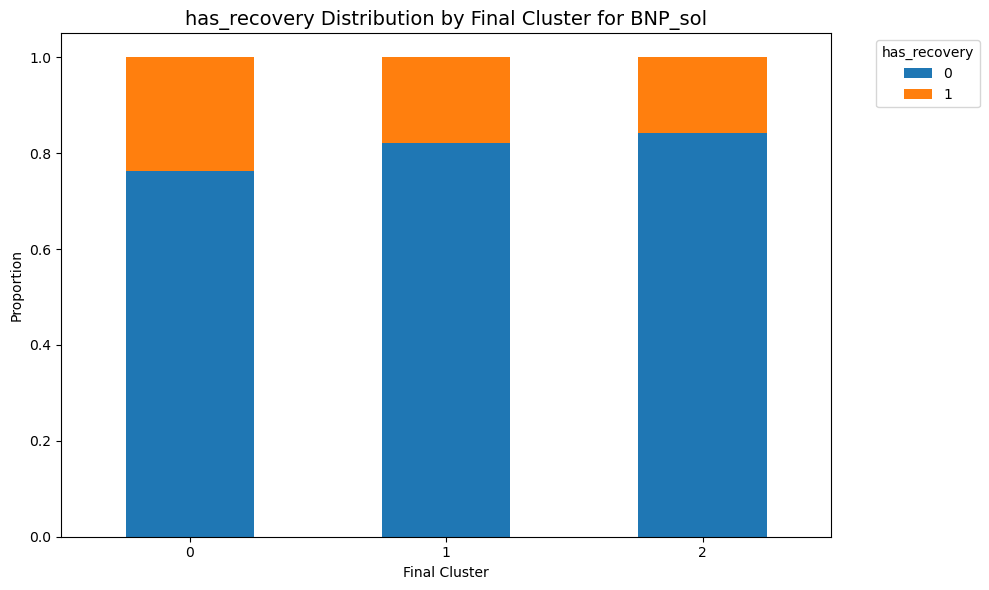

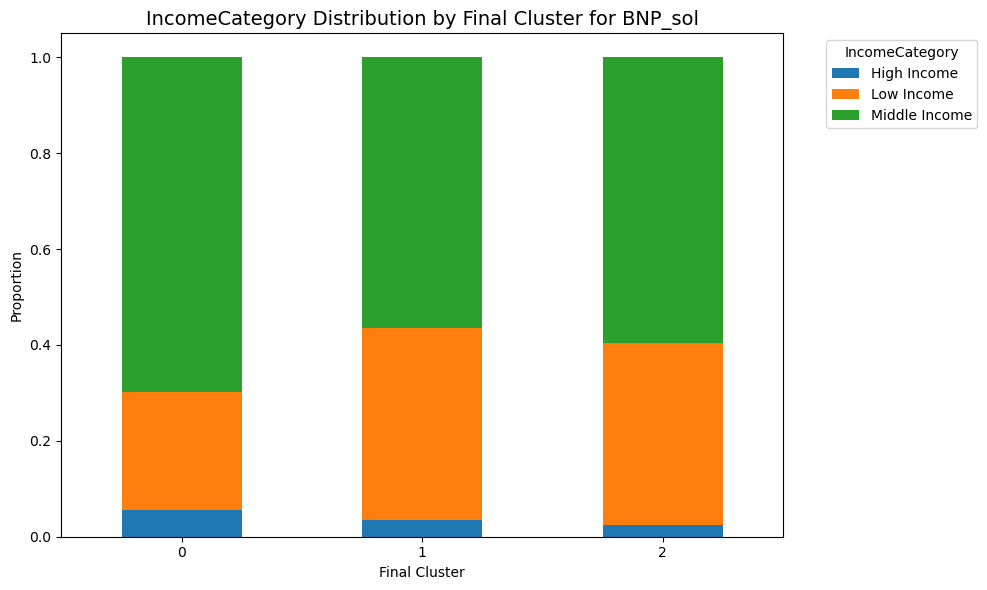

In [ ]:
for var in non_metric_features:
    ct = pd.crosstab(
        BNP_sol[cluster_col_sol],
        BNP_sol[var],
        normalize="index"
    )

    ax = ct.plot(
        kind="bar",
        stacked=True,
        figsize=(10,6)
    )

    ax.set_title(f"{var} Distribution by Final Cluster for BNP_sol", fontsize=14)
    ax.set_xlabel("Final Cluster")
    ax.set_ylabel("Proportion")

    ax.legend(
        title=var,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

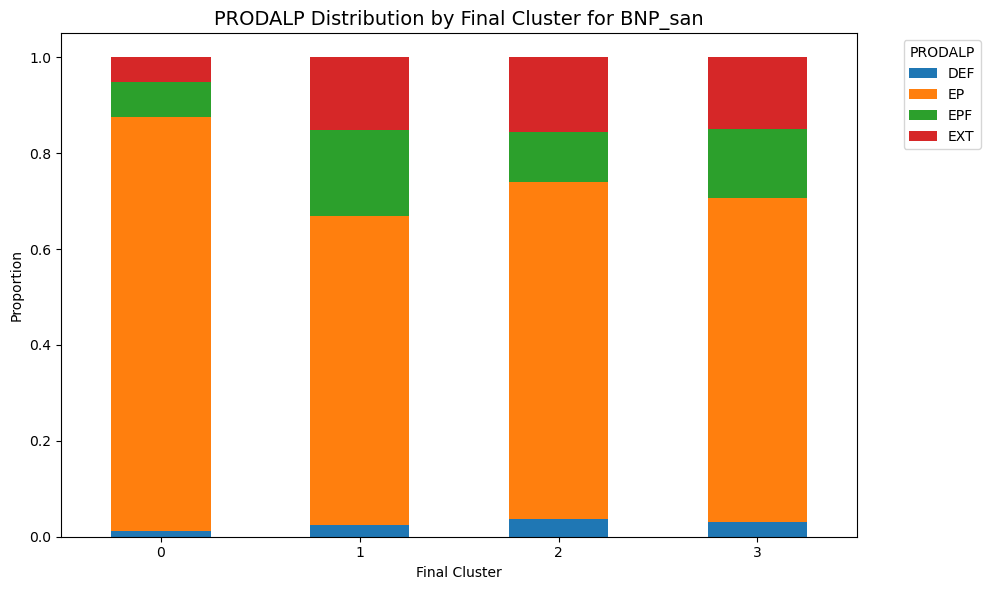

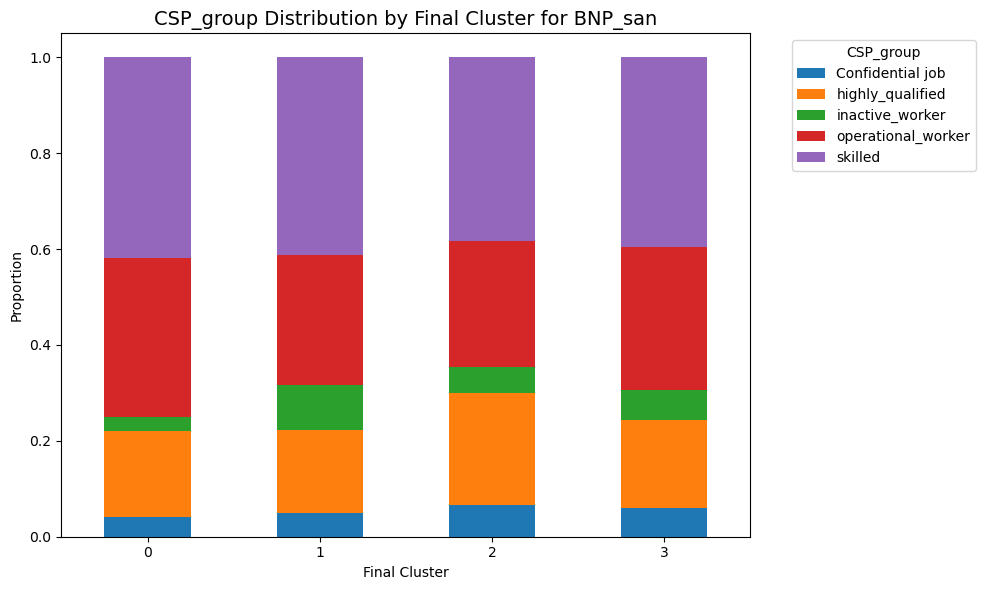

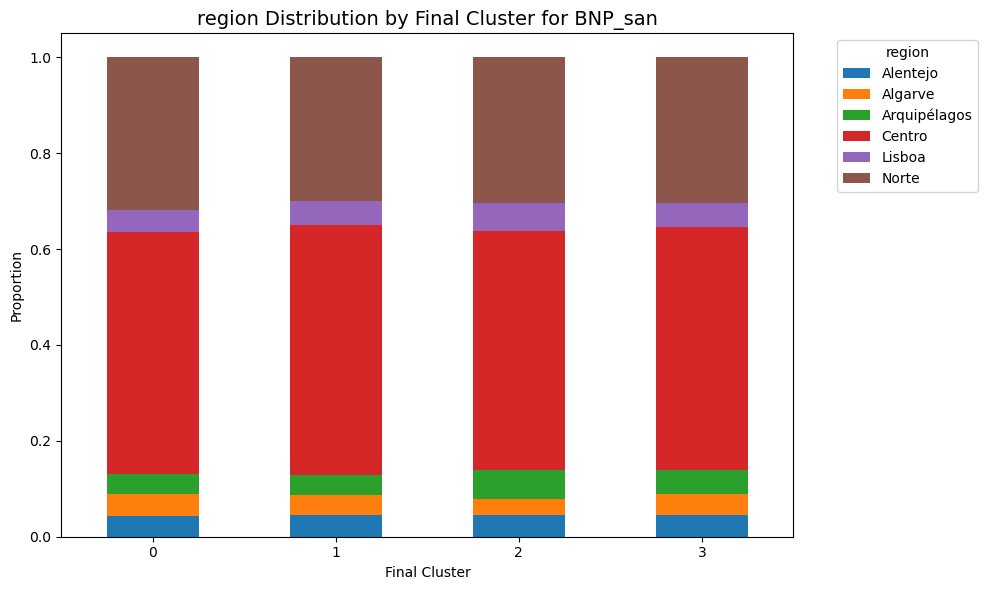

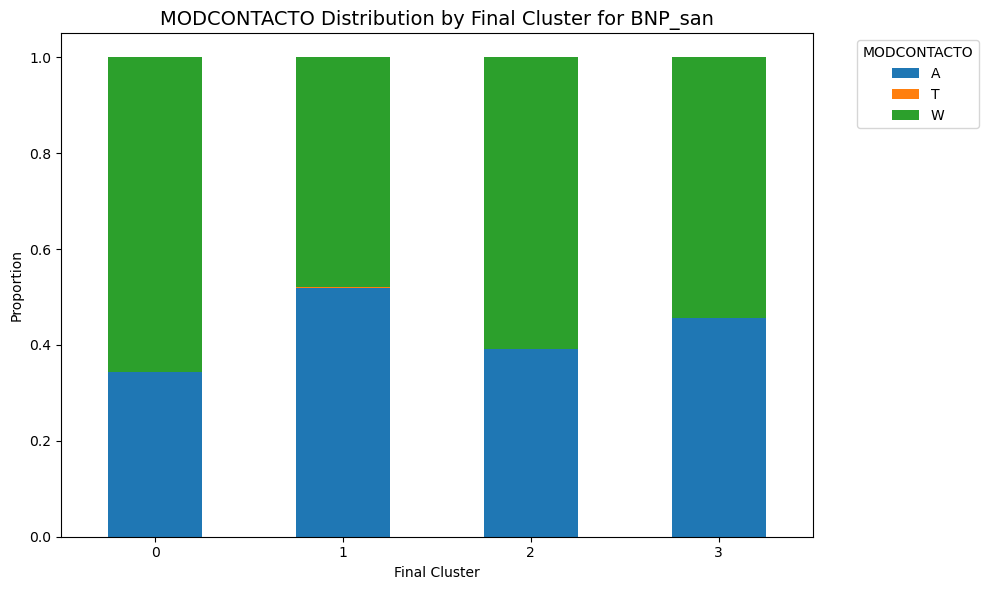

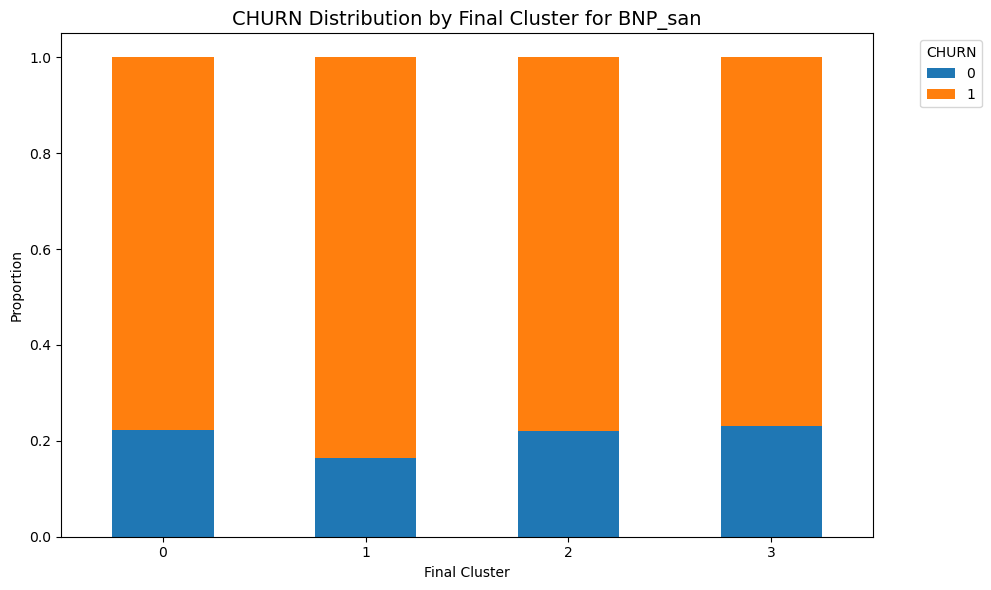

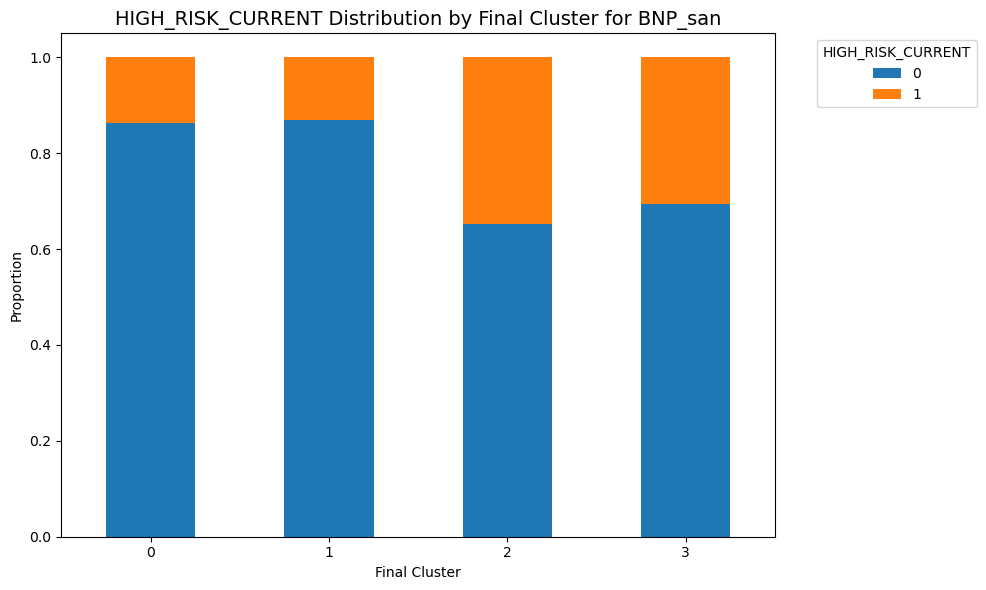

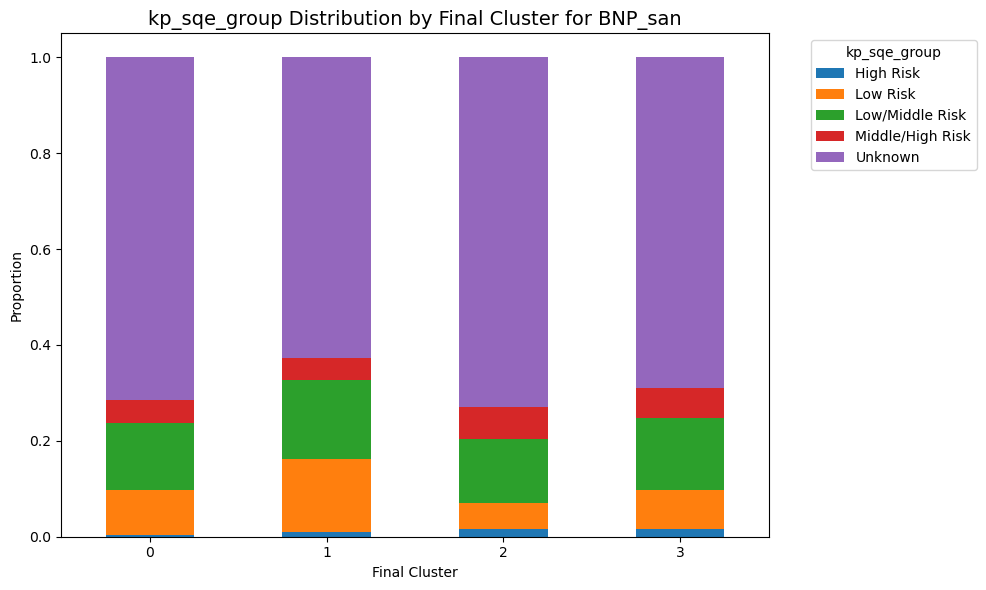

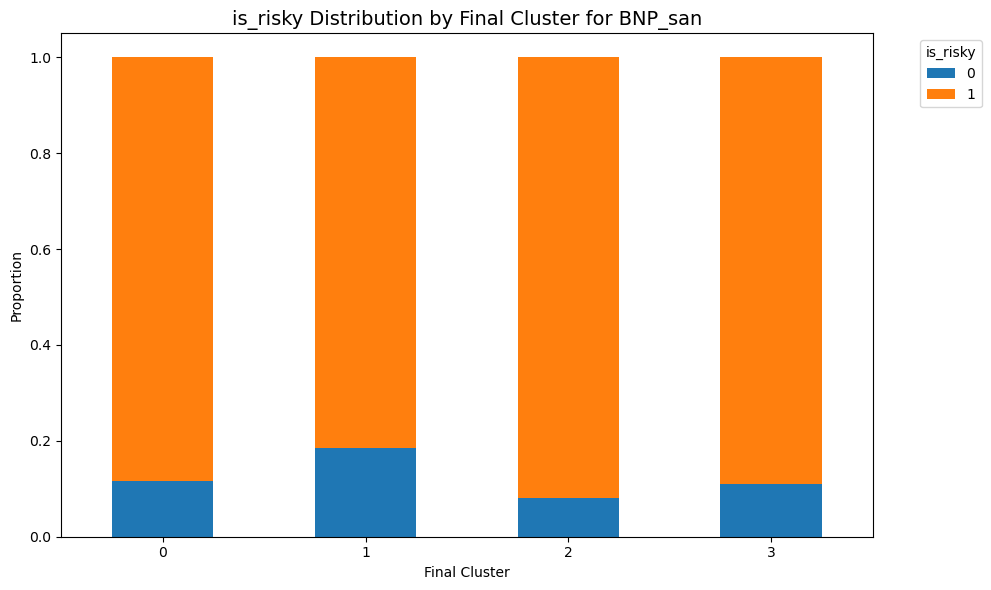

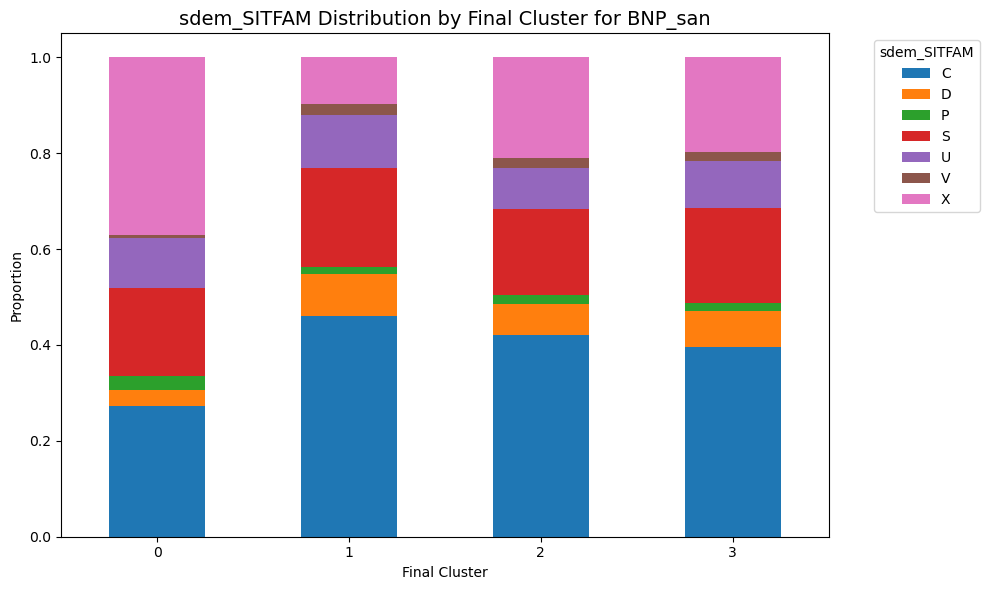

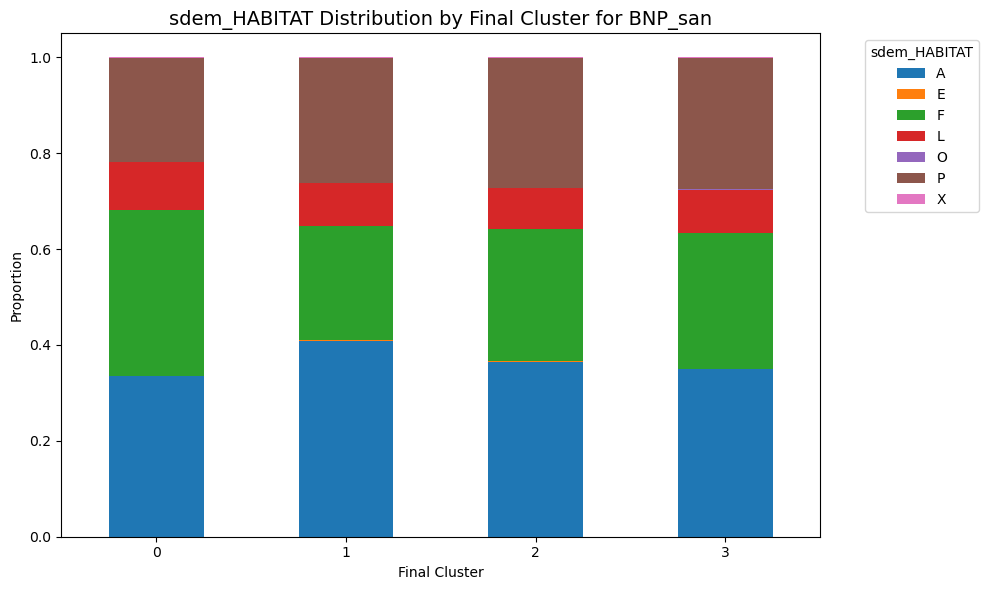

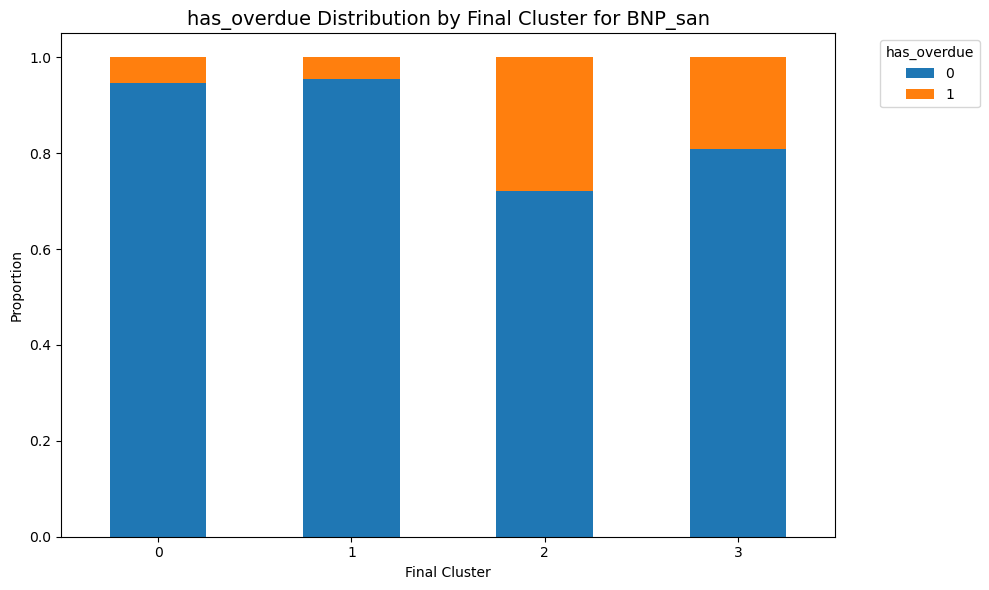

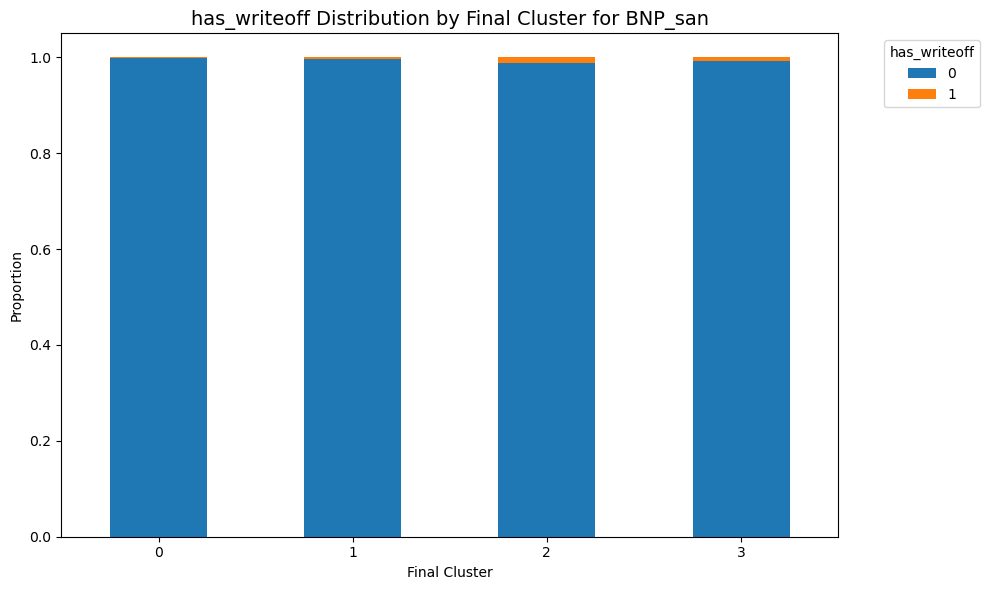

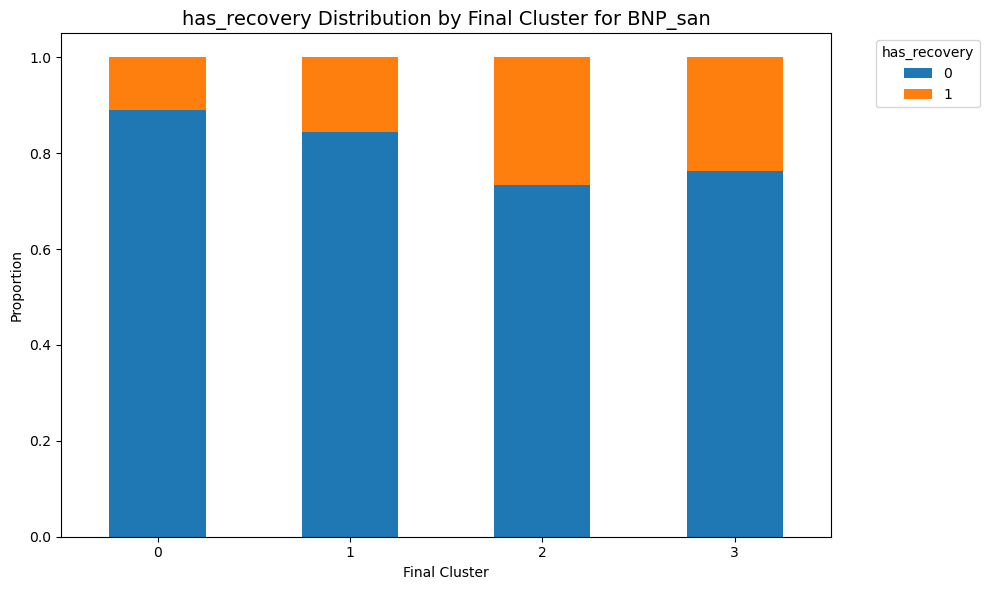

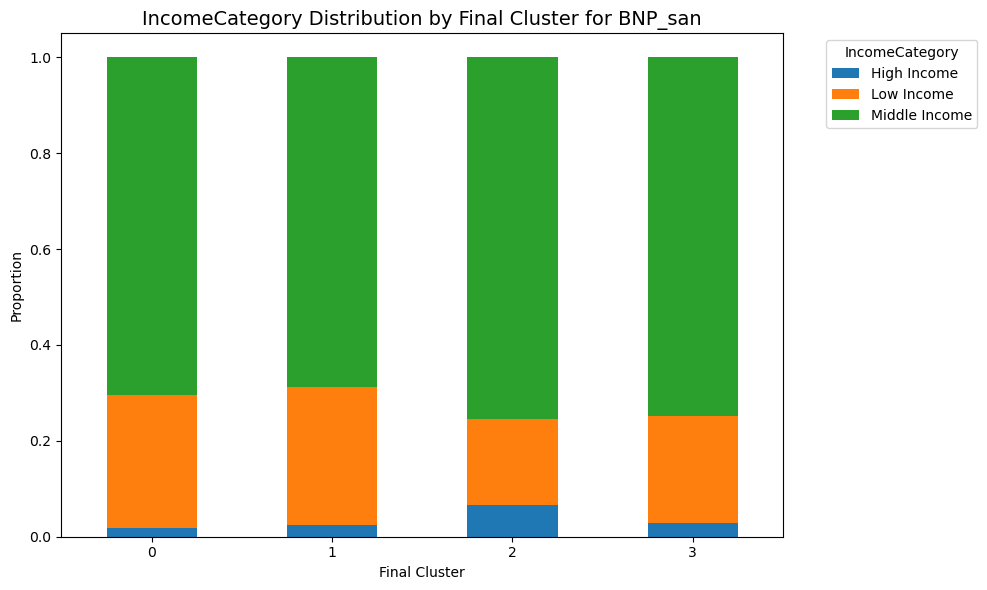

In [ ]:
for var in non_metric_features:
    ct = pd.crosstab(
        BNP_san[cluster_col_san],
        BNP_san[var],
        normalize="index"
    )

    ax = ct.plot(
        kind="bar",
        stacked=True,
        figsize=(10,6)
    )

    ax.set_title(f"{var} Distribution by Final Cluster for BNP_san", fontsize=14)
    ax.set_xlabel("Final Cluster")
    ax.set_ylabel("Proportion")

    ax.legend(
        title=var,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 7. Feature Importance


In [ ]:
def get_ss_variables(data):
    """Get the SS for each variable
    """
    ss_vars = data.var() * (data.count() - 1)
    return ss_vars

def r2_variables(data, labels):
    """Get the R² for each variable
    """
    sst_vars = get_ss_variables(data)
    ssw_vars = np.sum(data.groupby(labels).apply(get_ss_variables))
    return 1 - ssw_vars/sst_vars

In [ ]:
r2_feats_sol = r2_variables(BNP_sol[final_features + ['km_labels3_sol']], 'km_labels3_sol').drop('km_labels3_sol')
r2_feats_sol

C:\Users\martr\AppData\Local\Temp\ipykernel_8872\1761419925.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(data.groupby(labels).apply(get_ss_variables))
c:\Users\martr\OneDrive\Documentos\ANACONDA\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


ALLBD_N_events__N    0.107431
DURDEG               0.459505
NBEN_log             0.004087
count_cl             0.537116
montenc_total_log    0.044780
RANGCLI              0.420657
ks_score_tier_log    0.010220
sdem_age             0.097420
dtype: float64

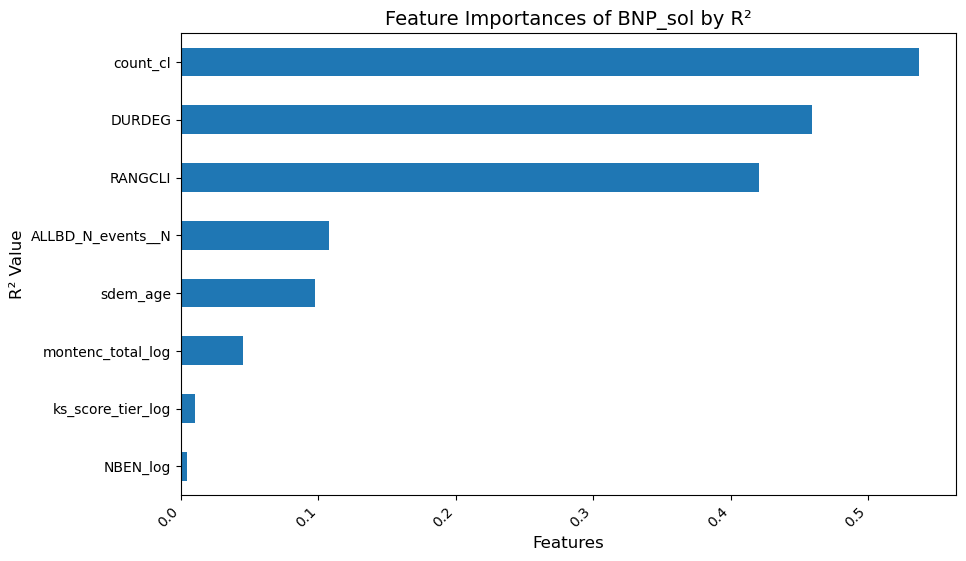

In [ ]:
r2_feats_sol.sort_values().plot.barh(figsize=(10,6))
plt.title("Feature Importances of BNP_sol by R²", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("R² Value", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.show()

In [ ]:
r2_feats_san = r2_variables(BNP_san[final_features + ['km_labels4_san']], 'km_labels4_san').drop('km_labels4_san')
r2_feats_san

C:\Users\martr\AppData\Local\Temp\ipykernel_8872\1761419925.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(data.groupby(labels).apply(get_ss_variables))
c:\Users\martr\OneDrive\Documentos\ANACONDA\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


ALLBD_N_events__N    0.157512
DURDEG               0.338105
NBEN_log             0.005569
count_cl             0.720105
montenc_total_log    0.056666
RANGCLI              0.279387
ks_score_tier_log    0.006140
sdem_age             0.064494
dtype: float64

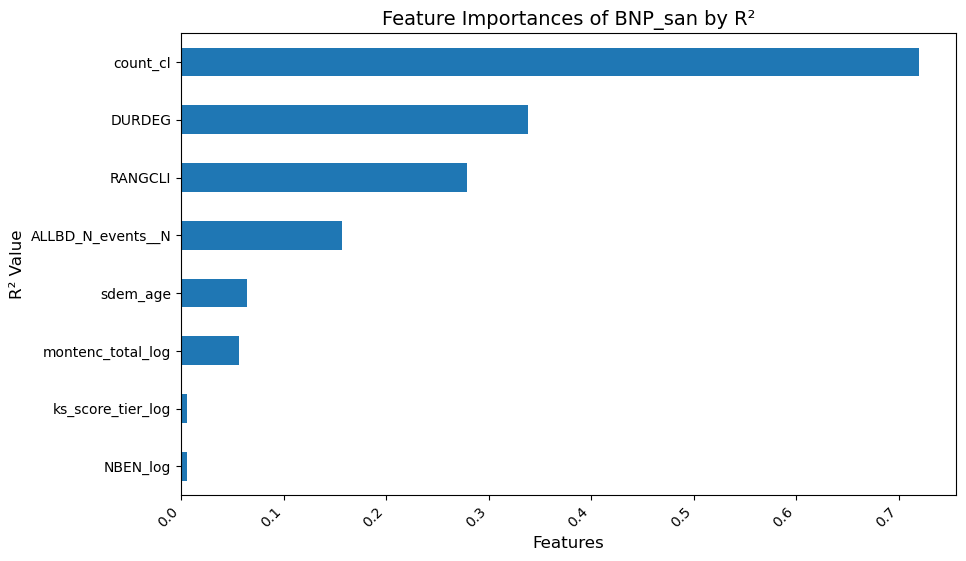

In [ ]:
r2_feats_san.sort_values().plot.barh(figsize=(10,6))
plt.title("Feature Importances of BNP_san by R²", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("R² Value", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.show()

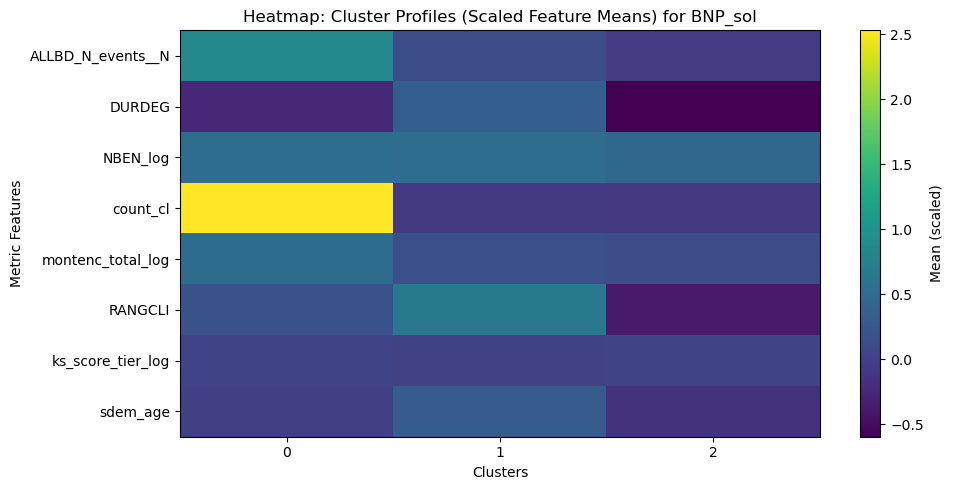

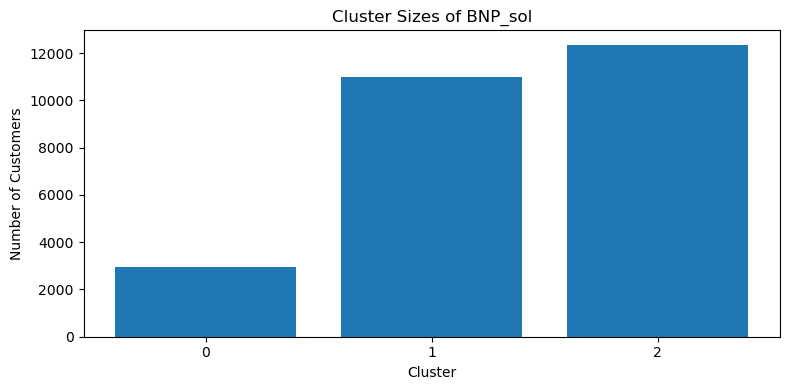

In [ ]:
# 1) Cluster means (on scaled data)
# =========================
cluster_means_sol = (
    BNP_sol
    .groupby(cluster_col_sol)[final_features]
    .mean()
)

# =========================
# 2) Heatmap (matplotlib only)
# =========================
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(cluster_means_sol.T.values, aspect="auto")

ax.set_title("Heatmap: Cluster Profiles (Scaled Feature Means) for BNP_sol")
ax.set_xlabel("Clusters")
ax.set_ylabel("Metric Features")

ax.set_xticks(range(cluster_means_sol.shape[0]))
ax.set_xticklabels(cluster_means_sol.index.astype(str))

ax.set_yticks(range(cluster_means_sol.shape[1]))
ax.set_yticklabels(cluster_means_sol.columns)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean (scaled)")

plt.tight_layout()
plt.show()

# =========================
# 3) Cluster sizes
# =========================
cluster_sizes_sol = (
    BNP_sol[cluster_col_sol]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(cluster_sizes_sol.index.astype(str), cluster_sizes_sol.values)
plt.title("Cluster Sizes of BNP_sol")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

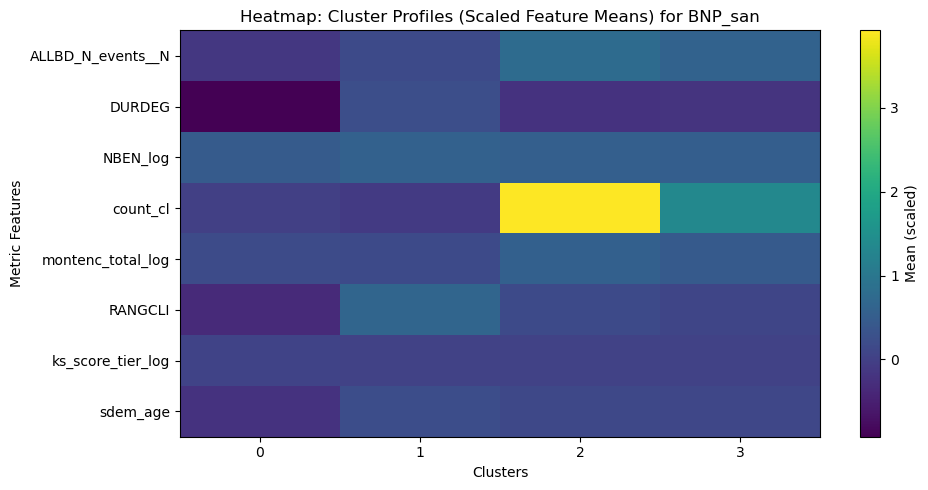

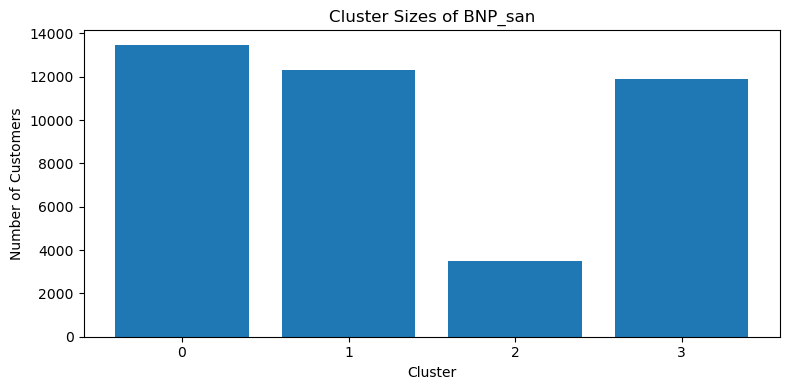

In [ ]:
# 1) Cluster means (on scaled data)
# =========================
cluster_means_san = (
    BNP_san
    .groupby(cluster_col_san)[final_features]
    .mean()
)

# =========================
# 2) Heatmap (matplotlib only)
# =========================
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(cluster_means_san.T.values, aspect="auto")

ax.set_title("Heatmap: Cluster Profiles (Scaled Feature Means) for BNP_san")
ax.set_xlabel("Clusters")
ax.set_ylabel("Metric Features")

ax.set_xticks(range(cluster_means_san.shape[0]))
ax.set_xticklabels(cluster_means_san.index.astype(str))

ax.set_yticks(range(cluster_means_san.shape[1]))
ax.set_yticklabels(cluster_means_san.columns)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean (scaled)")

plt.tight_layout()
plt.show()

# =========================
# 3) Cluster sizes
# =========================
cluster_sizes_san = (
    BNP_san[cluster_col_san]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(cluster_sizes_san.index.astype(str), cluster_sizes_san.values)
plt.title("Cluster Sizes of BNP_san")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 8. Business Values


#### 8.1. Numerical features


In [ ]:
original_values = scaler_san.inverse_transform(BNP_san_scaled)
original_df = pd.DataFrame(original_values, columns=metric_features, index=BNP_san_scaled.index)

BNP_san['DURDEG'] = original_df['DURDEG']

In [ ]:
BNP_san['total_contract_value'] = BNP_san['MENSALIDADE'] * BNP_san['DURDEG']
margin = 0.05 #assumption

avg_revenue_per_client = BNP_san['total_contract_value'].median() * margin
print(avg_revenue_per_client)

529.5252607252319


In [ ]:
unique_san_clients = len(BNP_san[BNP_san['km_labels4_san'] == 3])

assumed_churn_prob = 0.15

clients_at_risk_churn = int(unique_san_clients * assumed_churn_prob)
amount_saved_churn = clients_at_risk_churn * avg_revenue_per_client
print(amount_saved_churn)

943614.0146123632


In [ ]:
#assuming all customers settled halfway of the contract
amount_saved_halfway = unique_san_clients * avg_revenue_per_client * 0.5
print(amount_saved_halfway)

3145380.0487078773
